# **OpenPyTEA** Walkthrough — Part 3: Cost Analysis and Sensitivity

This notebook is **Part 3** of the OpenPyTEA walkthrough series:

1. [Part 1: Defining Equipment](part_1_equipment.ipynb)
2. [Part 2: Creating the Plant](part_2_plant.ipynb)
3. **Part 3: Cost Analysis and Sensitivity** (this notebook)
4. [Part 4: Monte Carlo Uncertainty Analysis](part_4_monte_carlo.ipynb)
5. [Part 5: TEA Using Configuration Files](part_5_configuration_files.ipynb)

## ⚙️ Setup

This part uses the equipment, the `psa` composite, and the fully configured `demo_plant`, which were built step by step in Parts 1 and 2. The cell below recreates them so this notebook can run on its own (make sure **OpenPyTEA** is installed, e.g. `%pip install "openpytea[ipython]"`).

In [1]:
from openpytea import Equipment

# The three pieces of equipment defined in Part 1 (usage examples 1, 2 and 4):
hx = Equipment(
    name="HX-101",
    param=900,                      # m² area
    process_type="Fluids",
    category="Heat Exchangers",
    type="U-tube shell & tube",
    material="316 stainless steel"
)

comp1 = Equipment(
    name='Comp-1',
    process_type='Fluids',
    material='Carbon steel',
    param=1,                        # MW
    category='Compressors, fans, & Blowers',
    type='Compressor, centrifugal',
    cost_func='co2_compressor_manzolini_2011'
)

comp2 = Equipment(
    name="Air Compressor",
    param=50_000,                   # exceeds upper_parallel -> auto-splits into parallel units
    process_type="Fluids",
    category='Compressors, fans, & blowers',
    type='Compressor, centrifugal',
)

In [2]:
from openpytea import CompositeEquipment

# The PSA composite equipment from Part 1 (usage example 10):
vessel = Equipment(
    name="Adsorber vessel",
    param=12.0,                        # volume of ONE vessel, m^3
    process_type="Fluids",
    category="Pressure vessels",
    type="Vertical",
    material="304 stainless steel",
    num_units=4,                       # four identical vessels
)
zeolite = Equipment(
    name="Zeolite 5A layer",
    param=4 * 250.0,                   # total bulk volume across the vessels, ft^3
    process_type="Solids",
    category="Packings & adsorbents",
    type="Molecular sieves",
)
carbon = Equipment(
    name="Activated carbon layer",
    param=None,
    process_type="Solids",
    category="Packings & adsorbents",
    type="Activated carbon",
    purchased_cost=38_000.0,           # vendor quote instead of a correlation
    cost_year=2021,
)
psa = CompositeEquipment(
    name="PSA",
    process_type="Fluids",
    components=[vessel, zeolite, carbon],
    category="Adsorption",
    type="Pressure-swing adsorber",
)

In [3]:
from openpytea import Plant

# Consolidated configuration of the demo plant as it stands at the END of Part 2
# (the initial config plus every update_configuration() call made along the way).
config = {
    "plant_name": "Demo Plant",
    "process_type": "Fluids",
    "country": "United States",
    "region": "Gulf Coast",
    "loc_factor": 1.10,                         # overrides the country/region lookup
    "currency": "USD",
    "exchange_rate": 1.0,
    "equipment": [hx, comp1, comp2],
    "interest_rate": 0.08,
    "project_lifetime": 20,
    "plant_utilization": 0.90,
    "tax_rate": 0.25,

    # Capital cost factor overrides
    "fixed_capital_factors": {"osbl": 0.25, "de": 0.35},
    "fixed_capital_components": {"contingency": 15_000_000},

    # Operator labor details
    "operators_hired": 12,
    "operator_hourly_rate": {"rate": 42.0},
    "working_weeks_per_year": 46,
    "working_shifts_per_week": 5,
    "operating_shifts_per_day": 3,

    # Fixed OPEX overrides
    "fixed_opex_factors": {"maintenance": 0.06, "rent_of_land": 0.01, "rnd": 0.0},
    "fixed_opex_components": {"supervision_costs": 100_000},

    # Plant products
    "plant_products": {
        "methanol": {"production": 100_000, "price": 1.95},   # main product
        "hydrogen": {"production": 75_000, "price": 1.25},    # by-product
    },

    # Variable operating expenses
    "variable_opex_inputs": {
        "electricity":   {"consumption": 1.4e6, "price": 0.075},
        "cooling_water": {"consumption": 1.6e6, "price": 0.0007},
        "steam":         {"consumption": 4.0e5, "price": 0.02},
        "natural_gas":   {"consumption": 1.0e5, "price": 0.035},
    },

    # Additional CAPEX and OPEX information
    "working_capital": None,
    "additional_capex_cost": [500_000, 200_000],
    "additional_capex_years": [8, 15],

    # Cash flow profiles
    "capex_ramp": [0.2, 0.5, 0.2, 0.1],
    "production_ramp": [0, 0, 0, 0, 0.4, 0.8],

    # Depreciation: 200% declining balance
    "depreciation": {
        "method": "declining_balance",
        "life": 10,
        "db_factor": 2.0,
        "salvage_fraction": 0.1,
        "service_start_year": 2,
    },
}

demo_plant = Plant(config)
demo_plant.calculate_all()   # runs every calculation from Part 2 (CAPEX, OPEX, cash flow, NPV, LCOP, PBT, ROI, IRR)

## 📊 CAPEX and OPEX Breakdown Visualizations

Understanding how capital and operating costs are distributed is essential in techno-economic analysis. While aggregate metrics such as total CAPEX or levelized cost provide a high-level overview, they do not reveal which components dominate the overall cost structure. A detailed breakdown enables clearer identification of cost drivers, supports comparison across different process designs, and helps guide cost-reduction strategies.

In **OpenPyTEA**, cost breakdowns are handled in two steps:
1. **Data preparation** using functions from the analysis module:

In [4]:
from openpytea.analysis import *

2. **Visualization** using functions from the plotting module:

In [5]:
from openpytea.plotting import *

This separation allows users to reuse the processed data for custom visualization workflows if needed.

The following workflow is used to generate CAPEX and OPEX breakdowns:
- `direct_costs_data()` → prepares equipment-level CAPEX data
- `fixed_capital_data() `→ prepares total CAPEX breakdown (ISBL, OSBL, design and engineering, contingency, and optional additional CAPEX)
- `fixed_opex_data()` → prepares fixed operating cost breakdown
- `variable_opex_data()` → prepares variable operating cost breakdown
- `levelized_cost_data()` → prepares levelized cost of production (LCOP) breakdown (discounted CAPEX, OPEX, and side revenue)

These functions return structured data, which can then be visualized using:

- `plot_stacked_bar()` → creates stacked bar charts for cost breakdowns

Some examples:

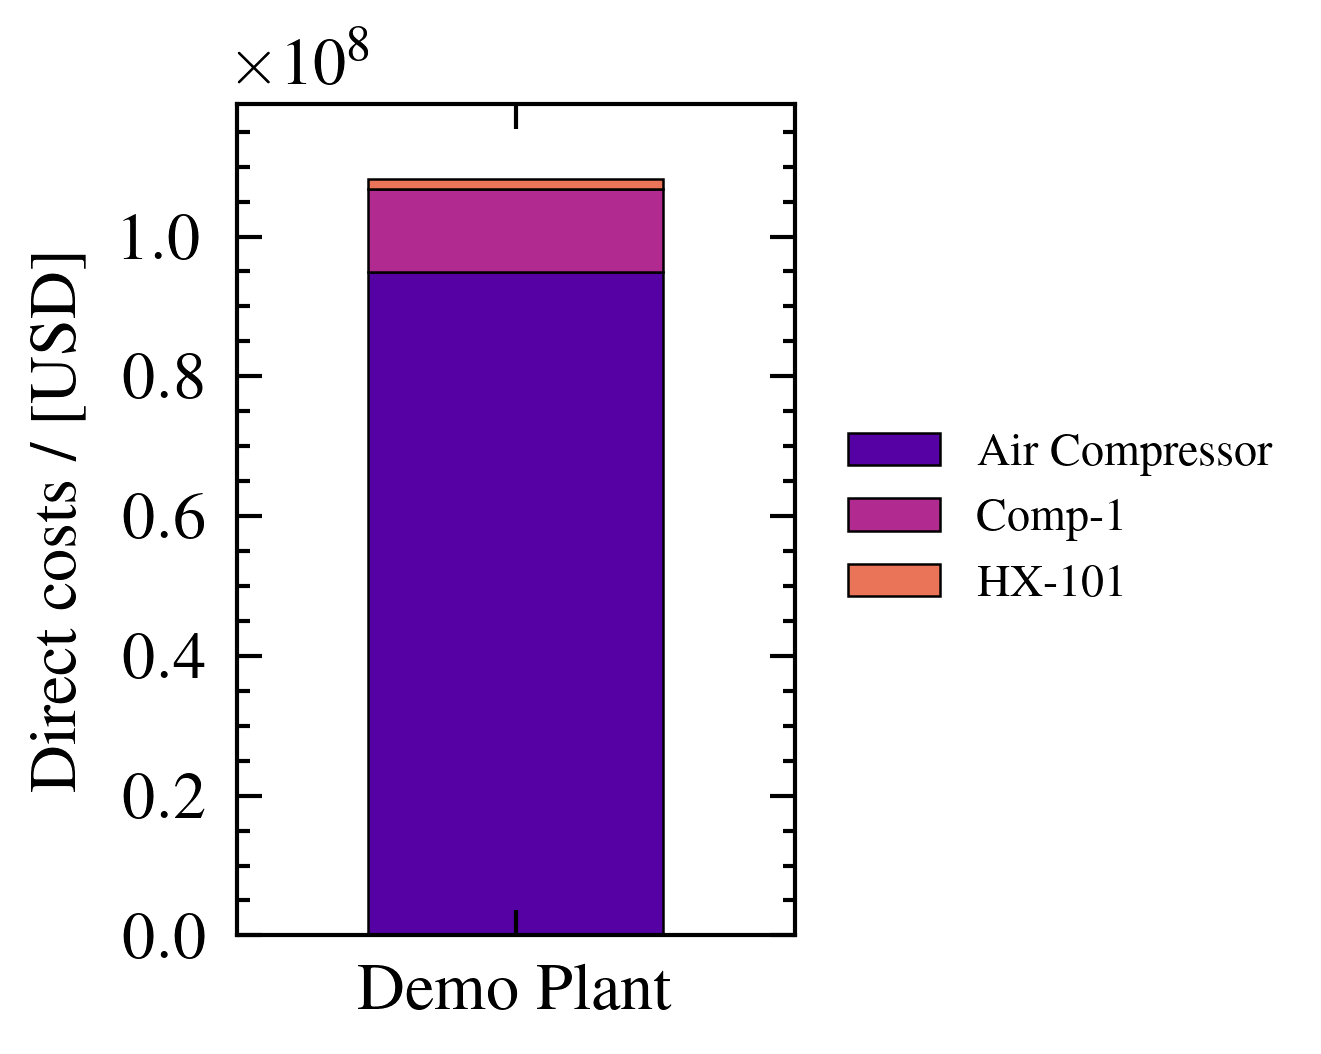

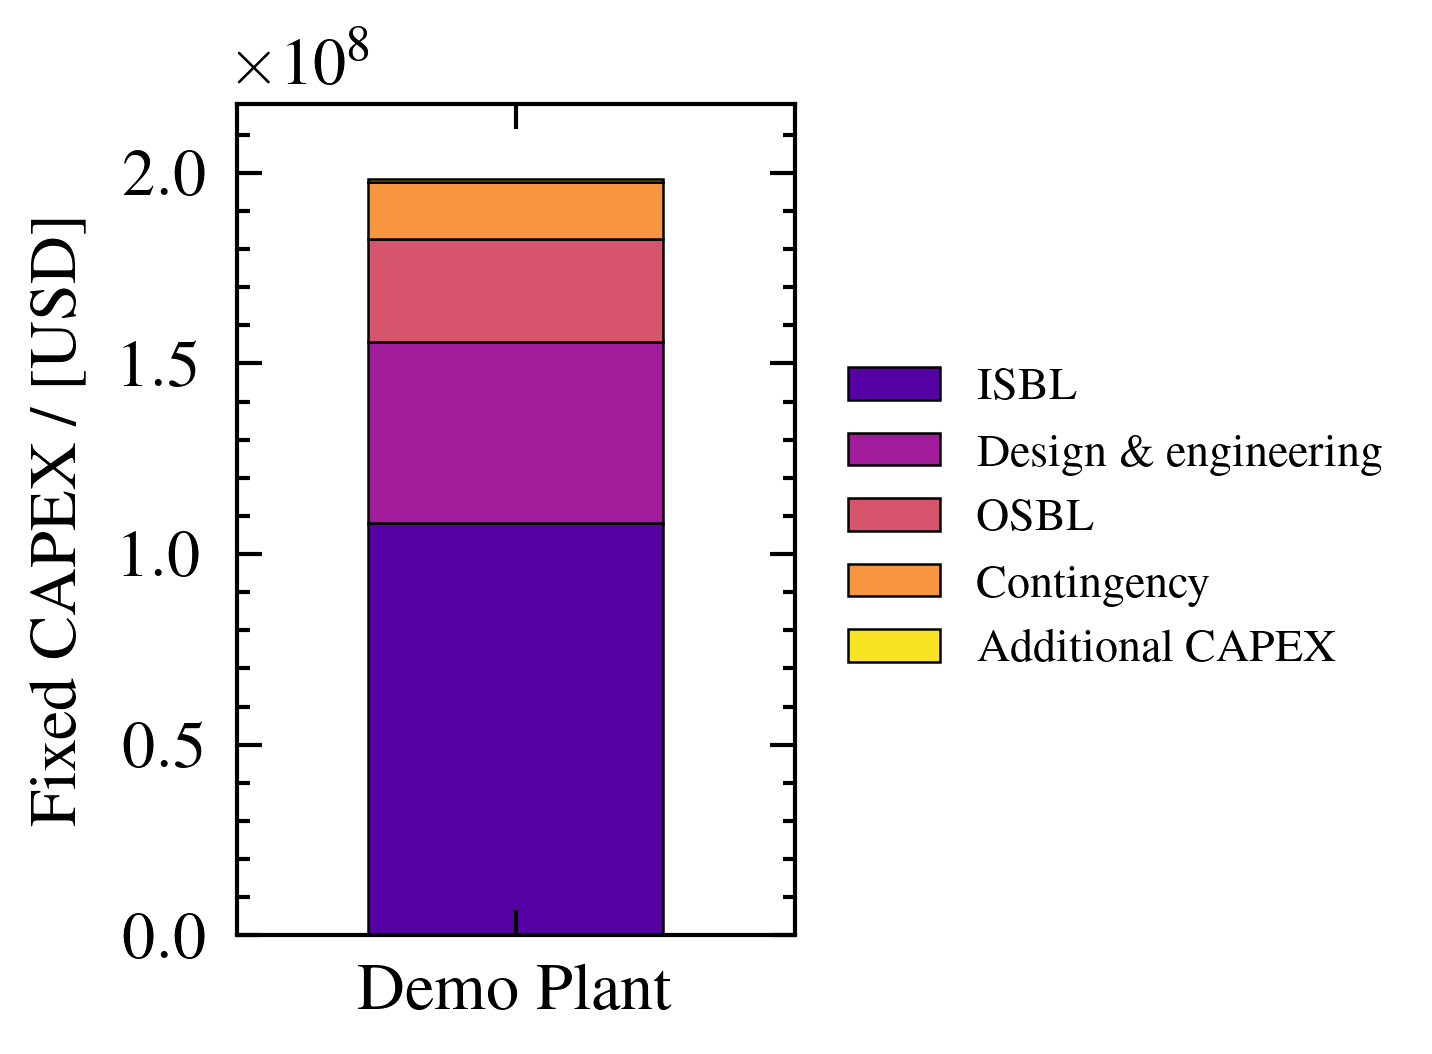

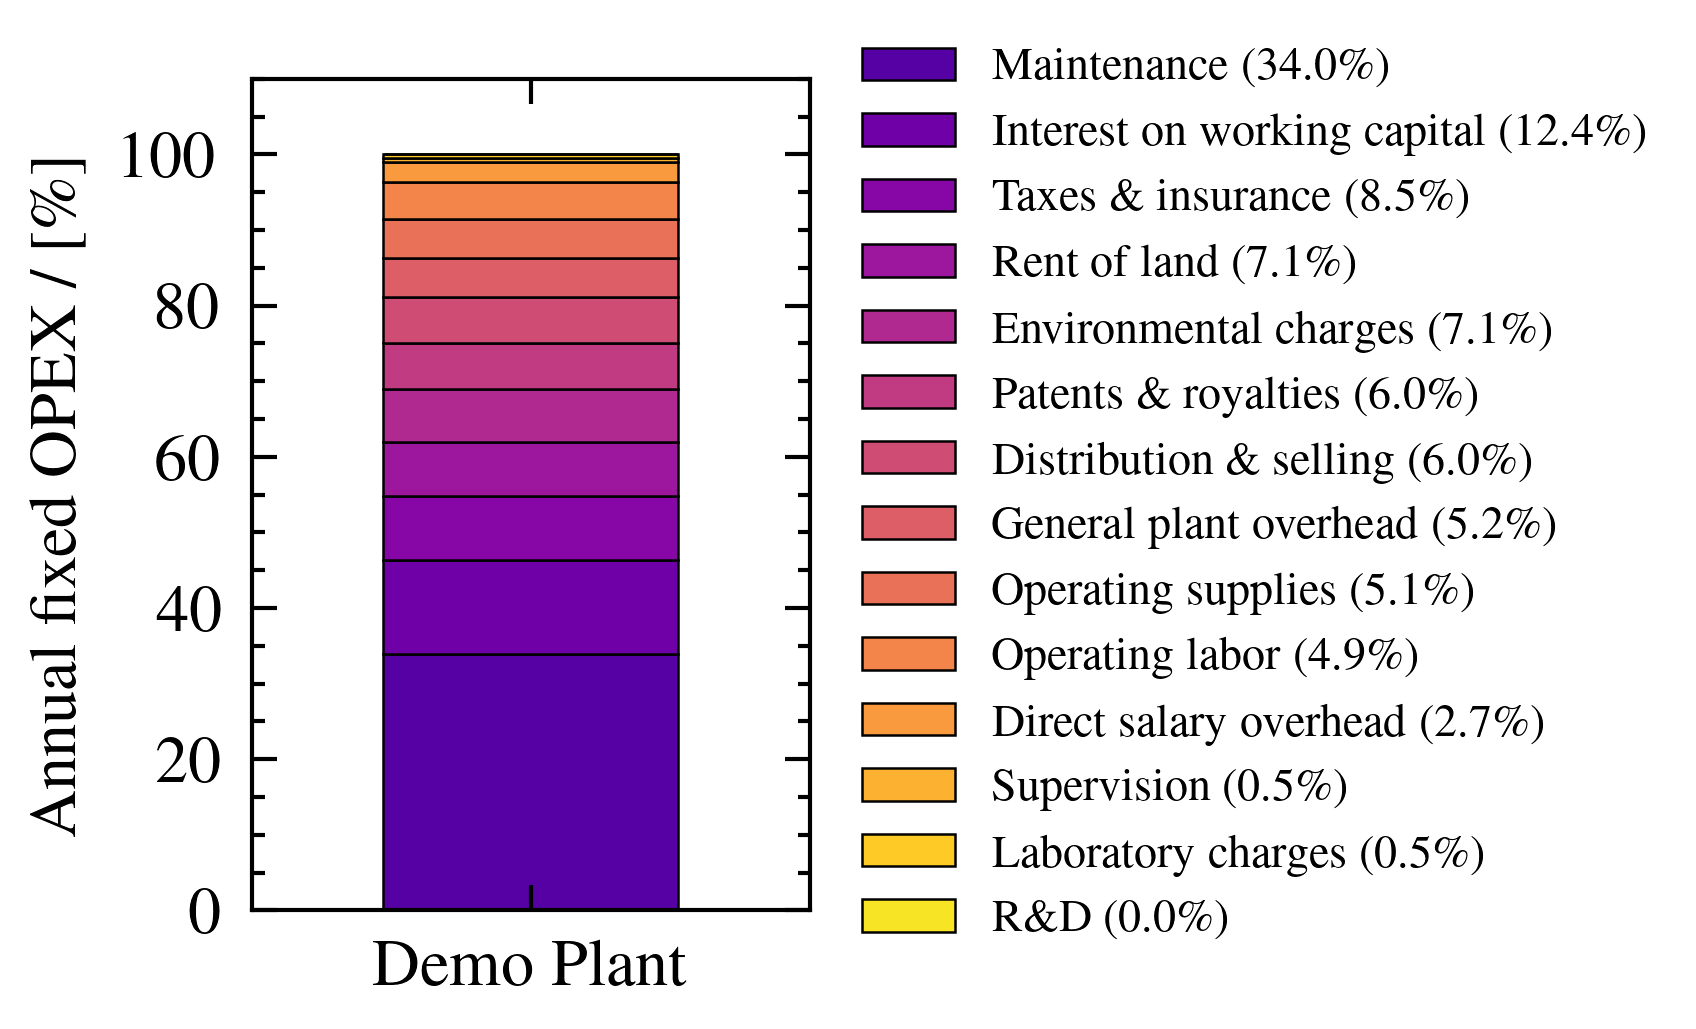

In [6]:
# --- Direct cost breakdown (equipment-level CAPEX) ---
direct_costs = direct_costs_data(plants=demo_plant)
fig, ax = plot_stacked_bar(direct_costs)

# --- Fixed capital breakdown (ISBL, OSBL, D&E, contingency, additional CAPEX) ---
fixed_capital = fixed_capital_data(plants=demo_plant, additional_capex=True)
fig, ax = plot_stacked_bar(fixed_capital)

# --- Fixed OPEX breakdown (shown as percentage of total fixed OPEX) ---
fixed_opex = fixed_opex_data(plants=demo_plant, pct=True)
fig, ax = plot_stacked_bar(fixed_opex)

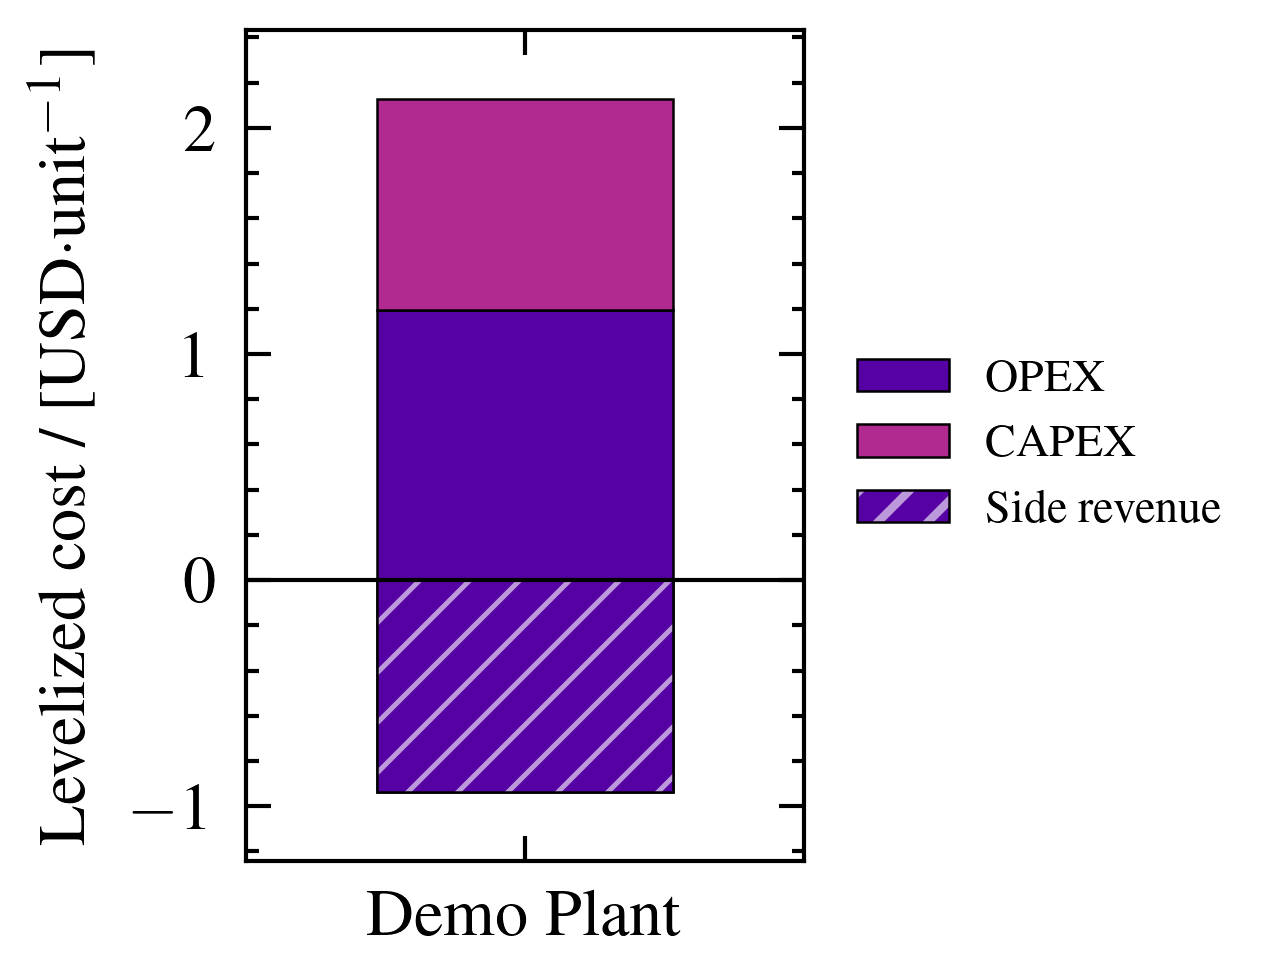

In [7]:
# --- Levelized cost breakdown (discounted CAPEX, OPEX, and side revenue) ---
levelized_cost = levelized_cost_data(plants=demo_plant)
fig, ax = plot_stacked_bar(levelized_cost)

A `CompositeEquipment` shows up as a single segment in the direct cost breakdown by default. To place the PSA defined in the Equipment section next to the demo plant's equipment, we copy the plant and extend its equipment list. Passing `expand_composites=True` to `direct_costs_data()` then splits every composite into its components (labelled `"composite / component"`), which sum to the same direct cost. `direct_cost_breakdown()` returns that split for a composite on its own, in the format `plot_stacked_bar()` expects.

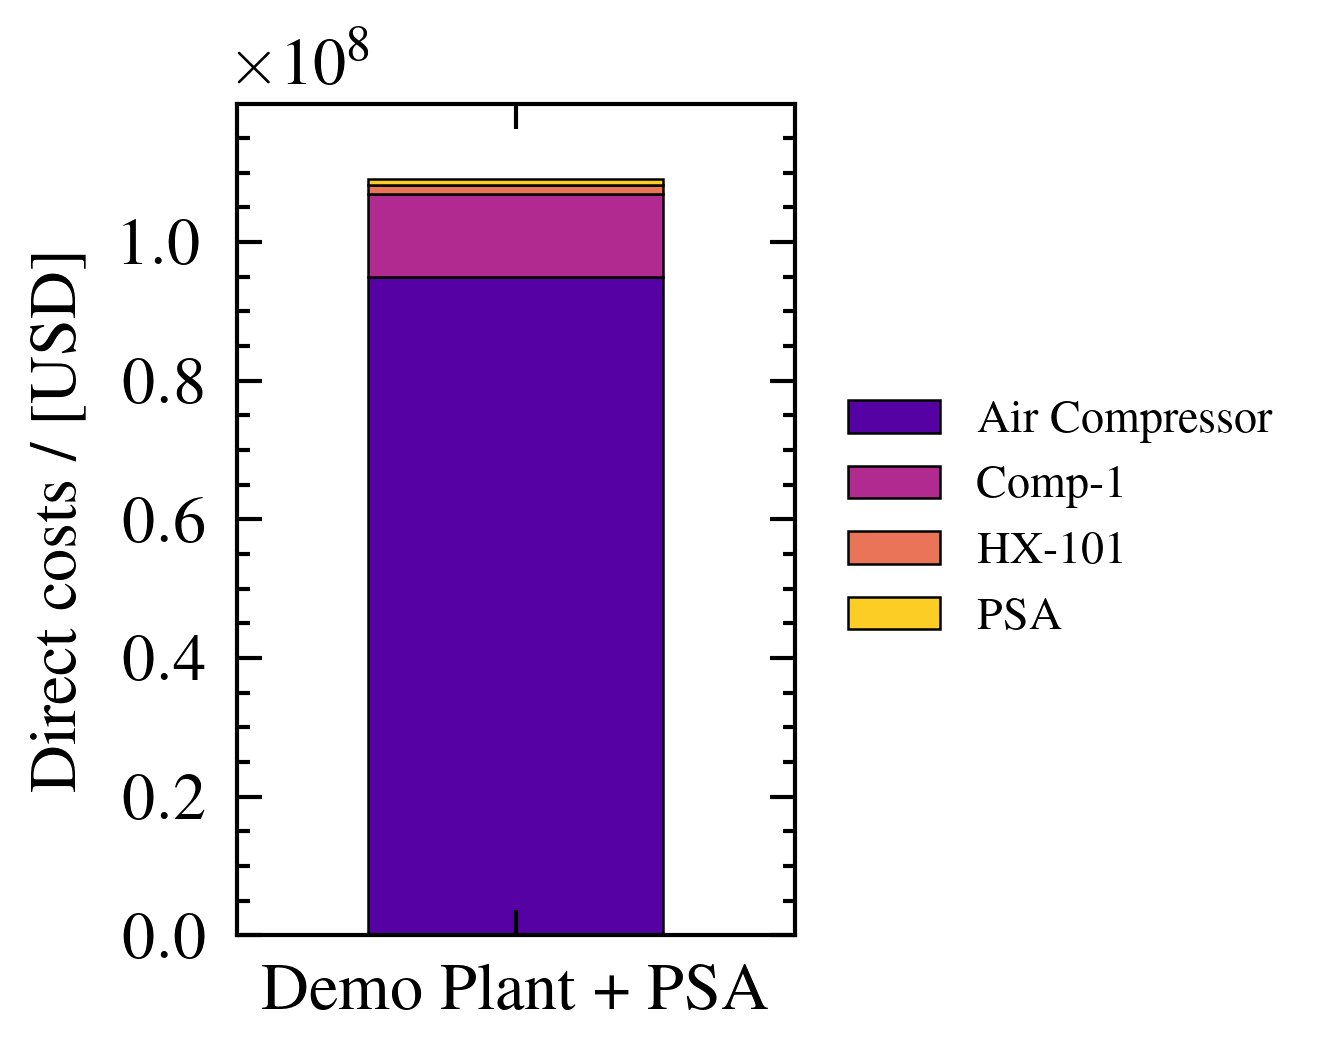

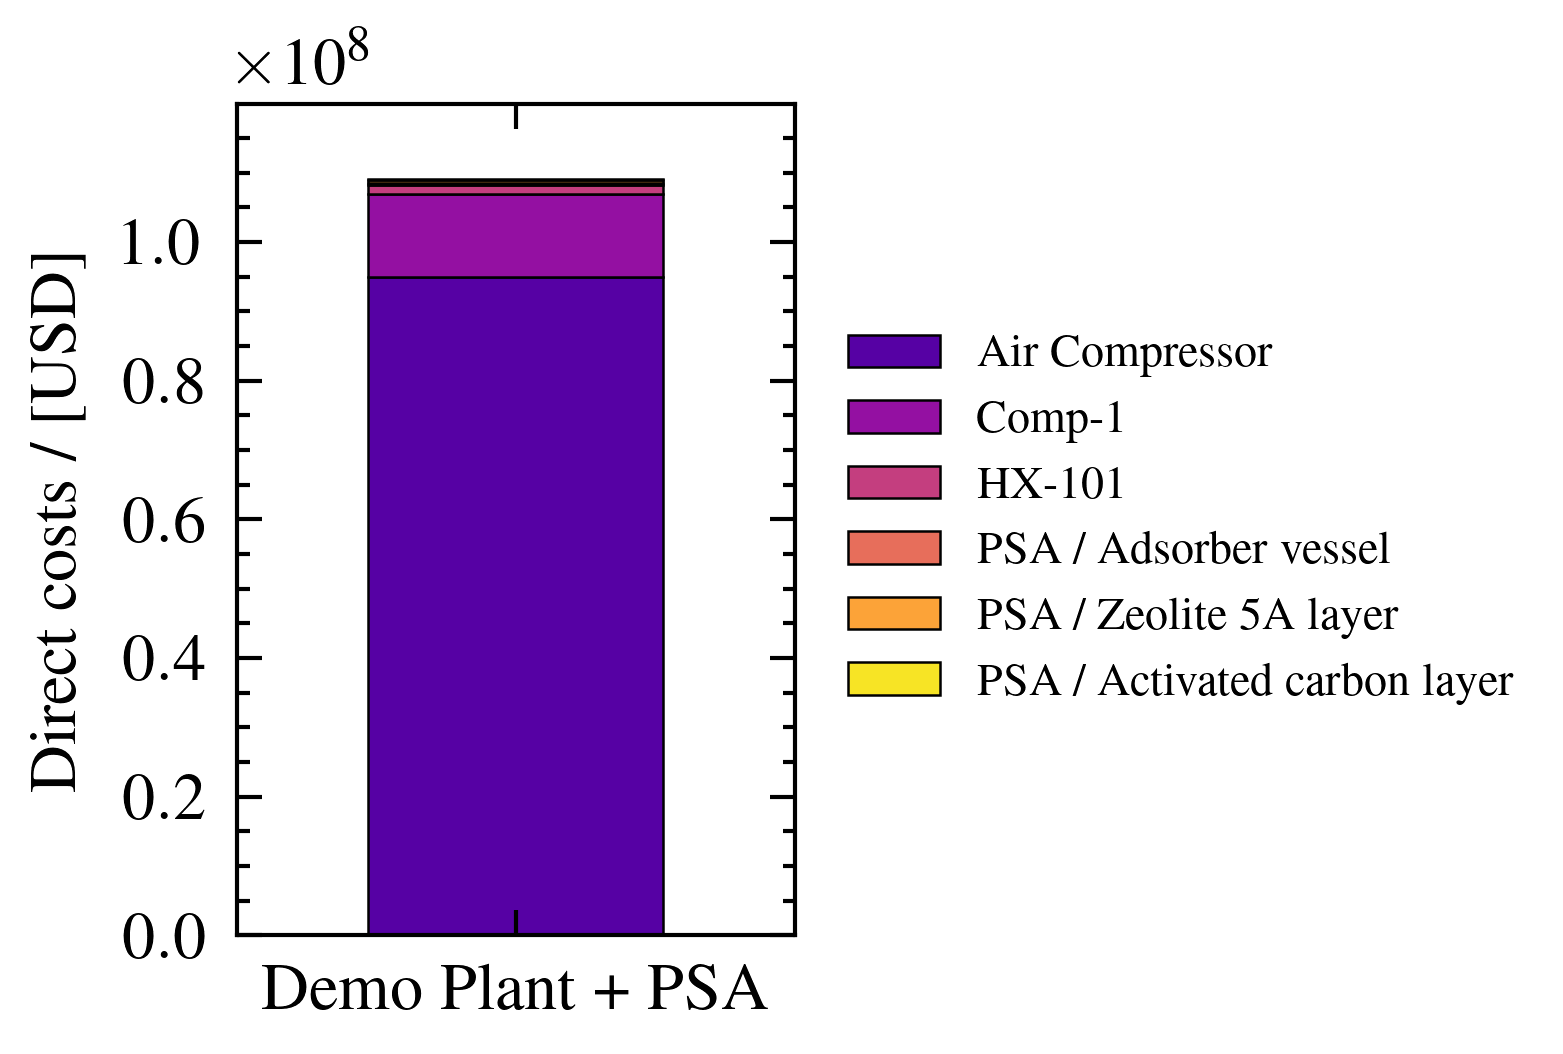

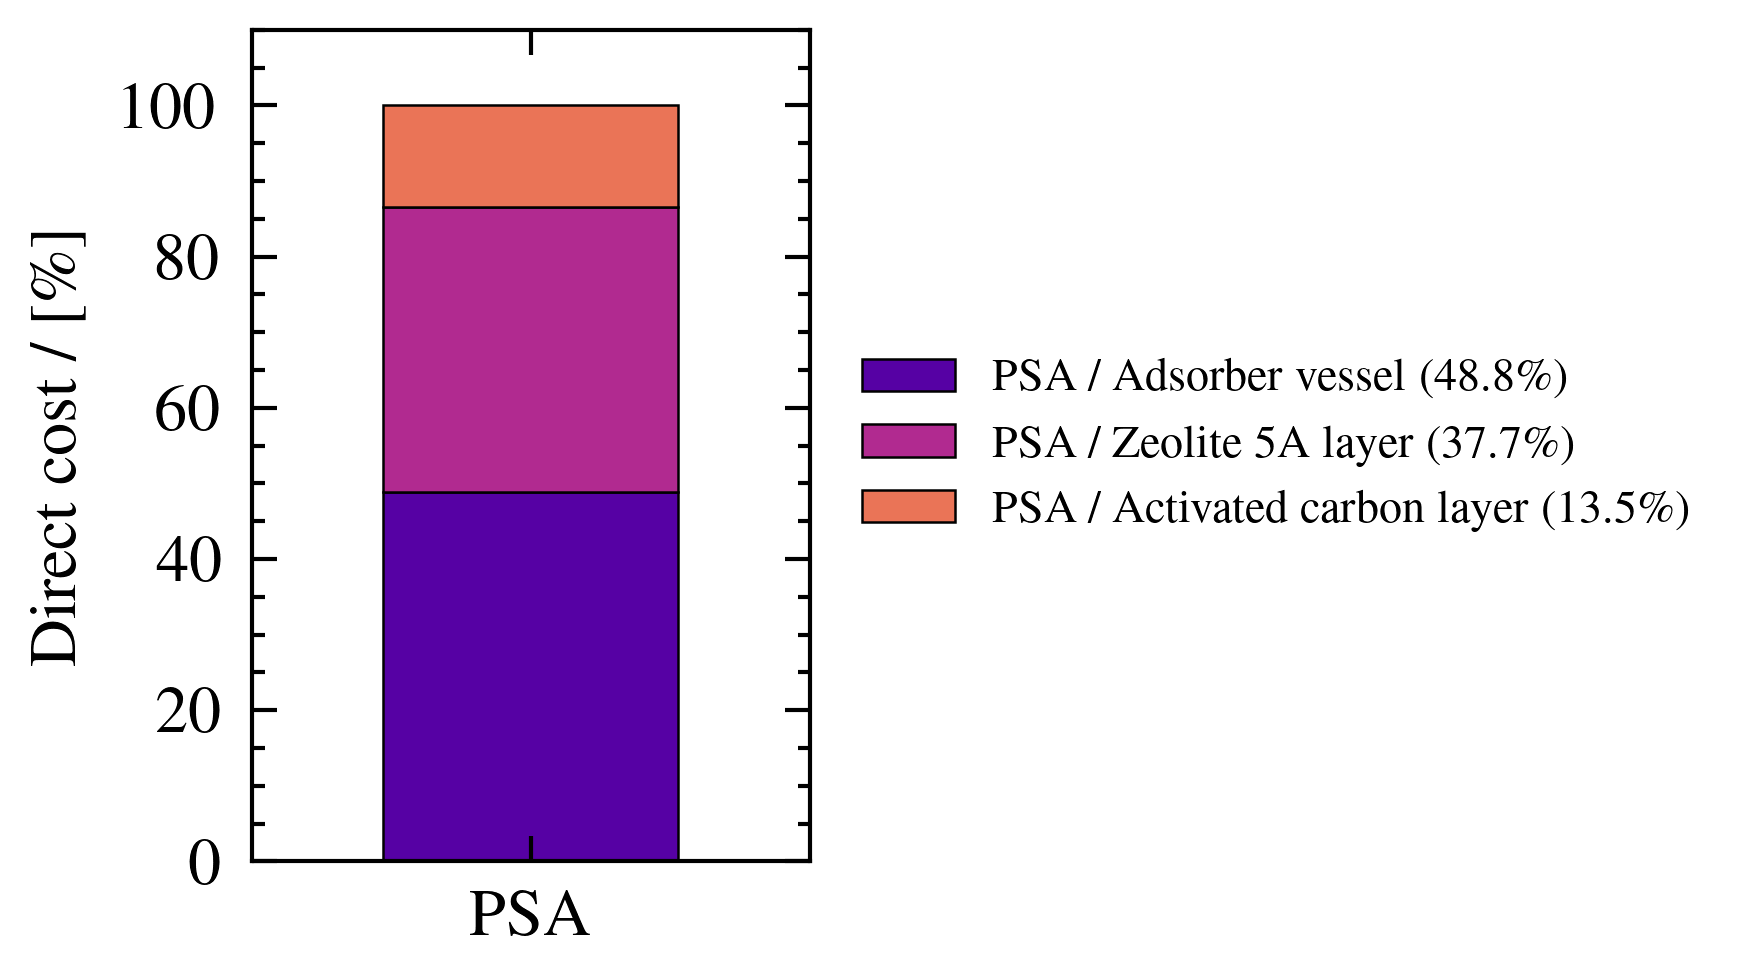

In [8]:
from copy import deepcopy

composite_plant = deepcopy(demo_plant)
composite_plant.update_configuration({
    "plant_name": "Demo Plant + PSA",
    "equipment": demo_plant.equipment_list + [psa],
})

# --- Composite as a single segment (default) ---
fig, ax = plot_stacked_bar(direct_costs_data(plants=composite_plant))

# --- Composite split into its components ---
fig, ax = plot_stacked_bar(direct_costs_data(plants=composite_plant, expand_composites=True))

# --- The composite on its own, as percentages ---
fig, ax = plot_stacked_bar({
    "components": [psa.direct_cost_breakdown()],
    "xlabels": [psa.name],
    "currency": composite_plant.currency,
    "pct": True,
    "ylabel": "Direct cost",
})

If we have multiple plants, we can plot the breakdown side-by-side for comparison:

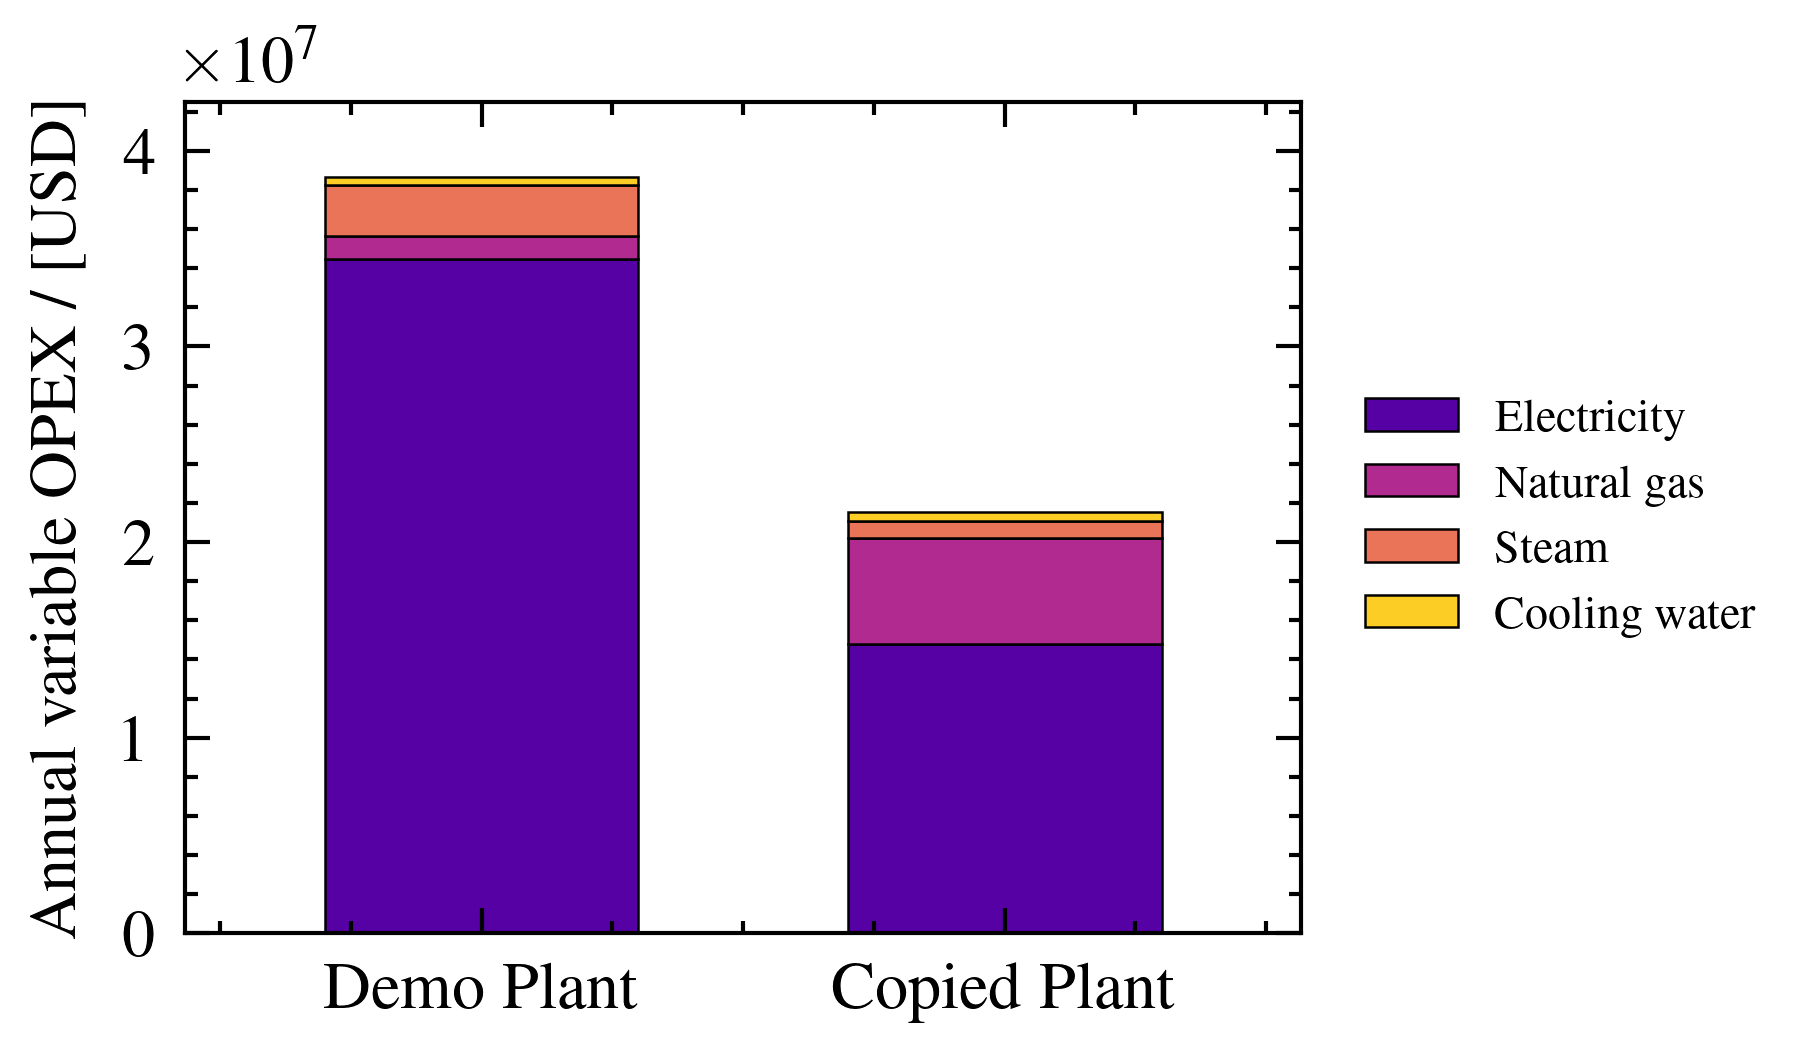

In [9]:
copy_plant = deepcopy(demo_plant)

config = {
    'plant_name': "Copied Plant",
    "variable_opex_inputs": {
        "electricity":   {"consumption": 0.9e6, "price": 0.05},
        "cooling_water": {"consumption": 2.0e6, "price": 0.0007},
        "steam":         {"consumption": 1.3e5, "price": 0.02},
        "natural_gas":   {"consumption": 1.1e6, "price": 0.015}
    },
}

copy_plant.update_configuration(config)

variable_opex = variable_opex_data(plants=[demo_plant, copy_plant])
fig, ax = plot_stacked_bar(variable_opex)  # We plot the variable OPEX bar for the copied plant with updated configuration

Every plotting function in OpenPyTEA returns a matplotlib `ax` object, so you can modify it further. For example:

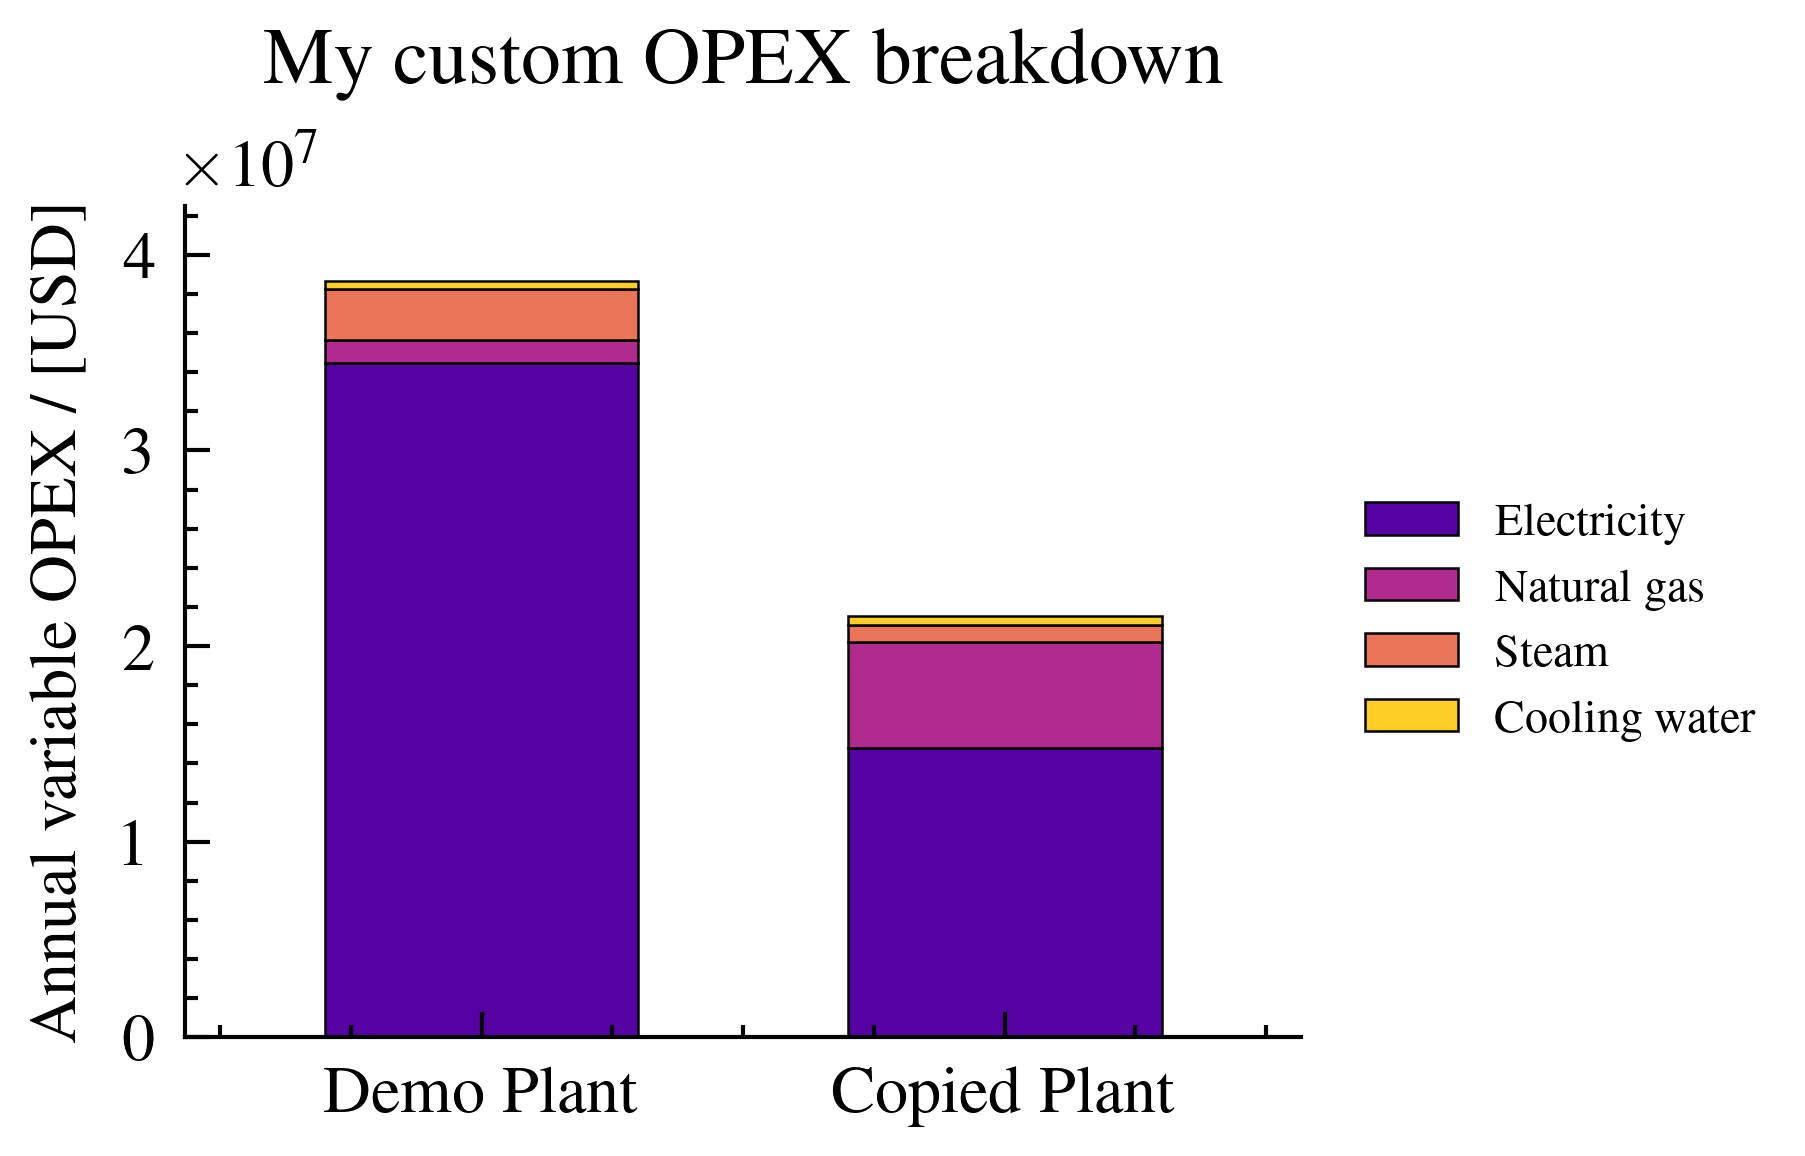

In [10]:
fig, ax = plot_stacked_bar(variable_opex_data(plants=[demo_plant, copy_plant]), show=False)
ax.set_title("My custom OPEX breakdown")
ax.spines[['right', 'top']].set_visible(False)
ax.tick_params(which='both', top=False, right=False)
plt.show()

## 💰 Cash Flow Diagram

Beyond static cost breakdowns, it is often useful to see how a project's cumulative cash position evolves over time: the dip into debt during construction, the point of maximum investment, the break-even (pay-back) point, and the eventual climb into profit.

**OpenPyTEA** provides this in the same two-step pattern as the other visualizations:
- `cash_flow_data()` → prepares the cumulative cash flow curve (and its max investment / break-even points) from `Plant.calculate_cash_flow()`
- `plot_cash_flow()` → draws the cumulative cash flow diagram, shading the region in debt and marking the break-even point

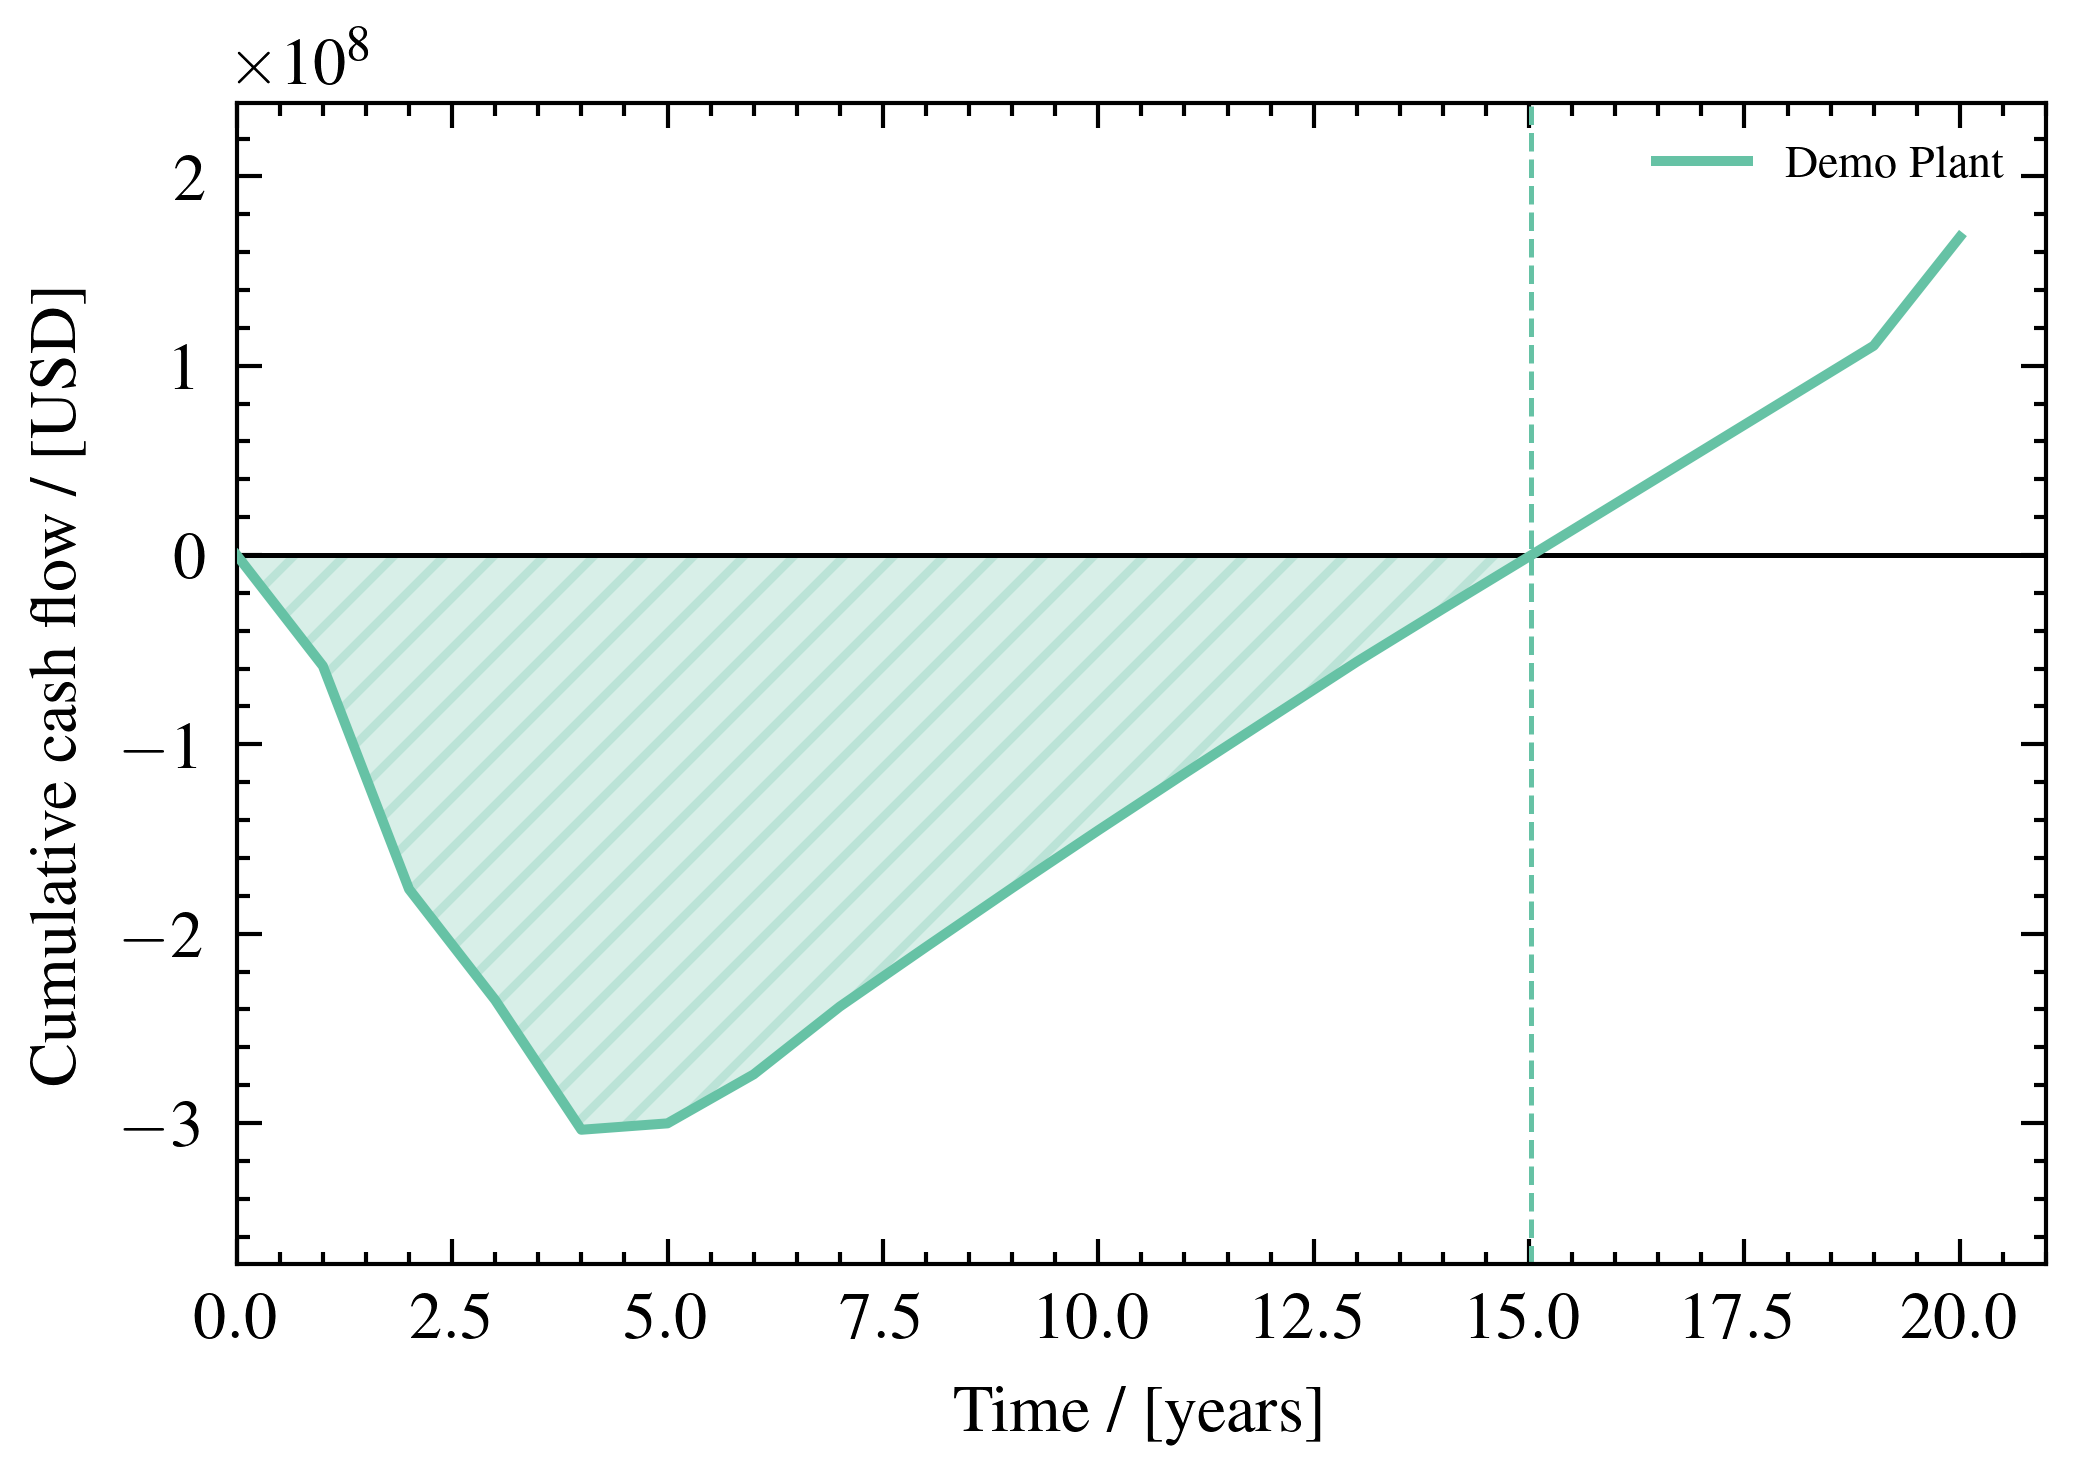

In [11]:
# --- Cumulative cash flow diagram for a single plant ---
cash_flow = cash_flow_data(demo_plant)
fig, ax = plot_cash_flow(cash_flow)

The returned dictionary also carries the key figures shown on the chart, which you can use directly (e.g. for reporting) without having to read them off the plot:

In [12]:
curve = cash_flow["curves"][0]
print(f"Maximum investment: {curve['max_investment']:,.0f} at year {curve['max_investment_year']:.1f}")
print(f"Pay-back time: {curve['payback_time']:.1f} years")

Maximum investment: 303,591,310 at year 4.0
Pay-back time: 15.0 years


As with the other breakdowns, passing a list of plants overlays their cumulative cash flow curves — each with its own shaded debt region and break-even line — for a direct comparison:

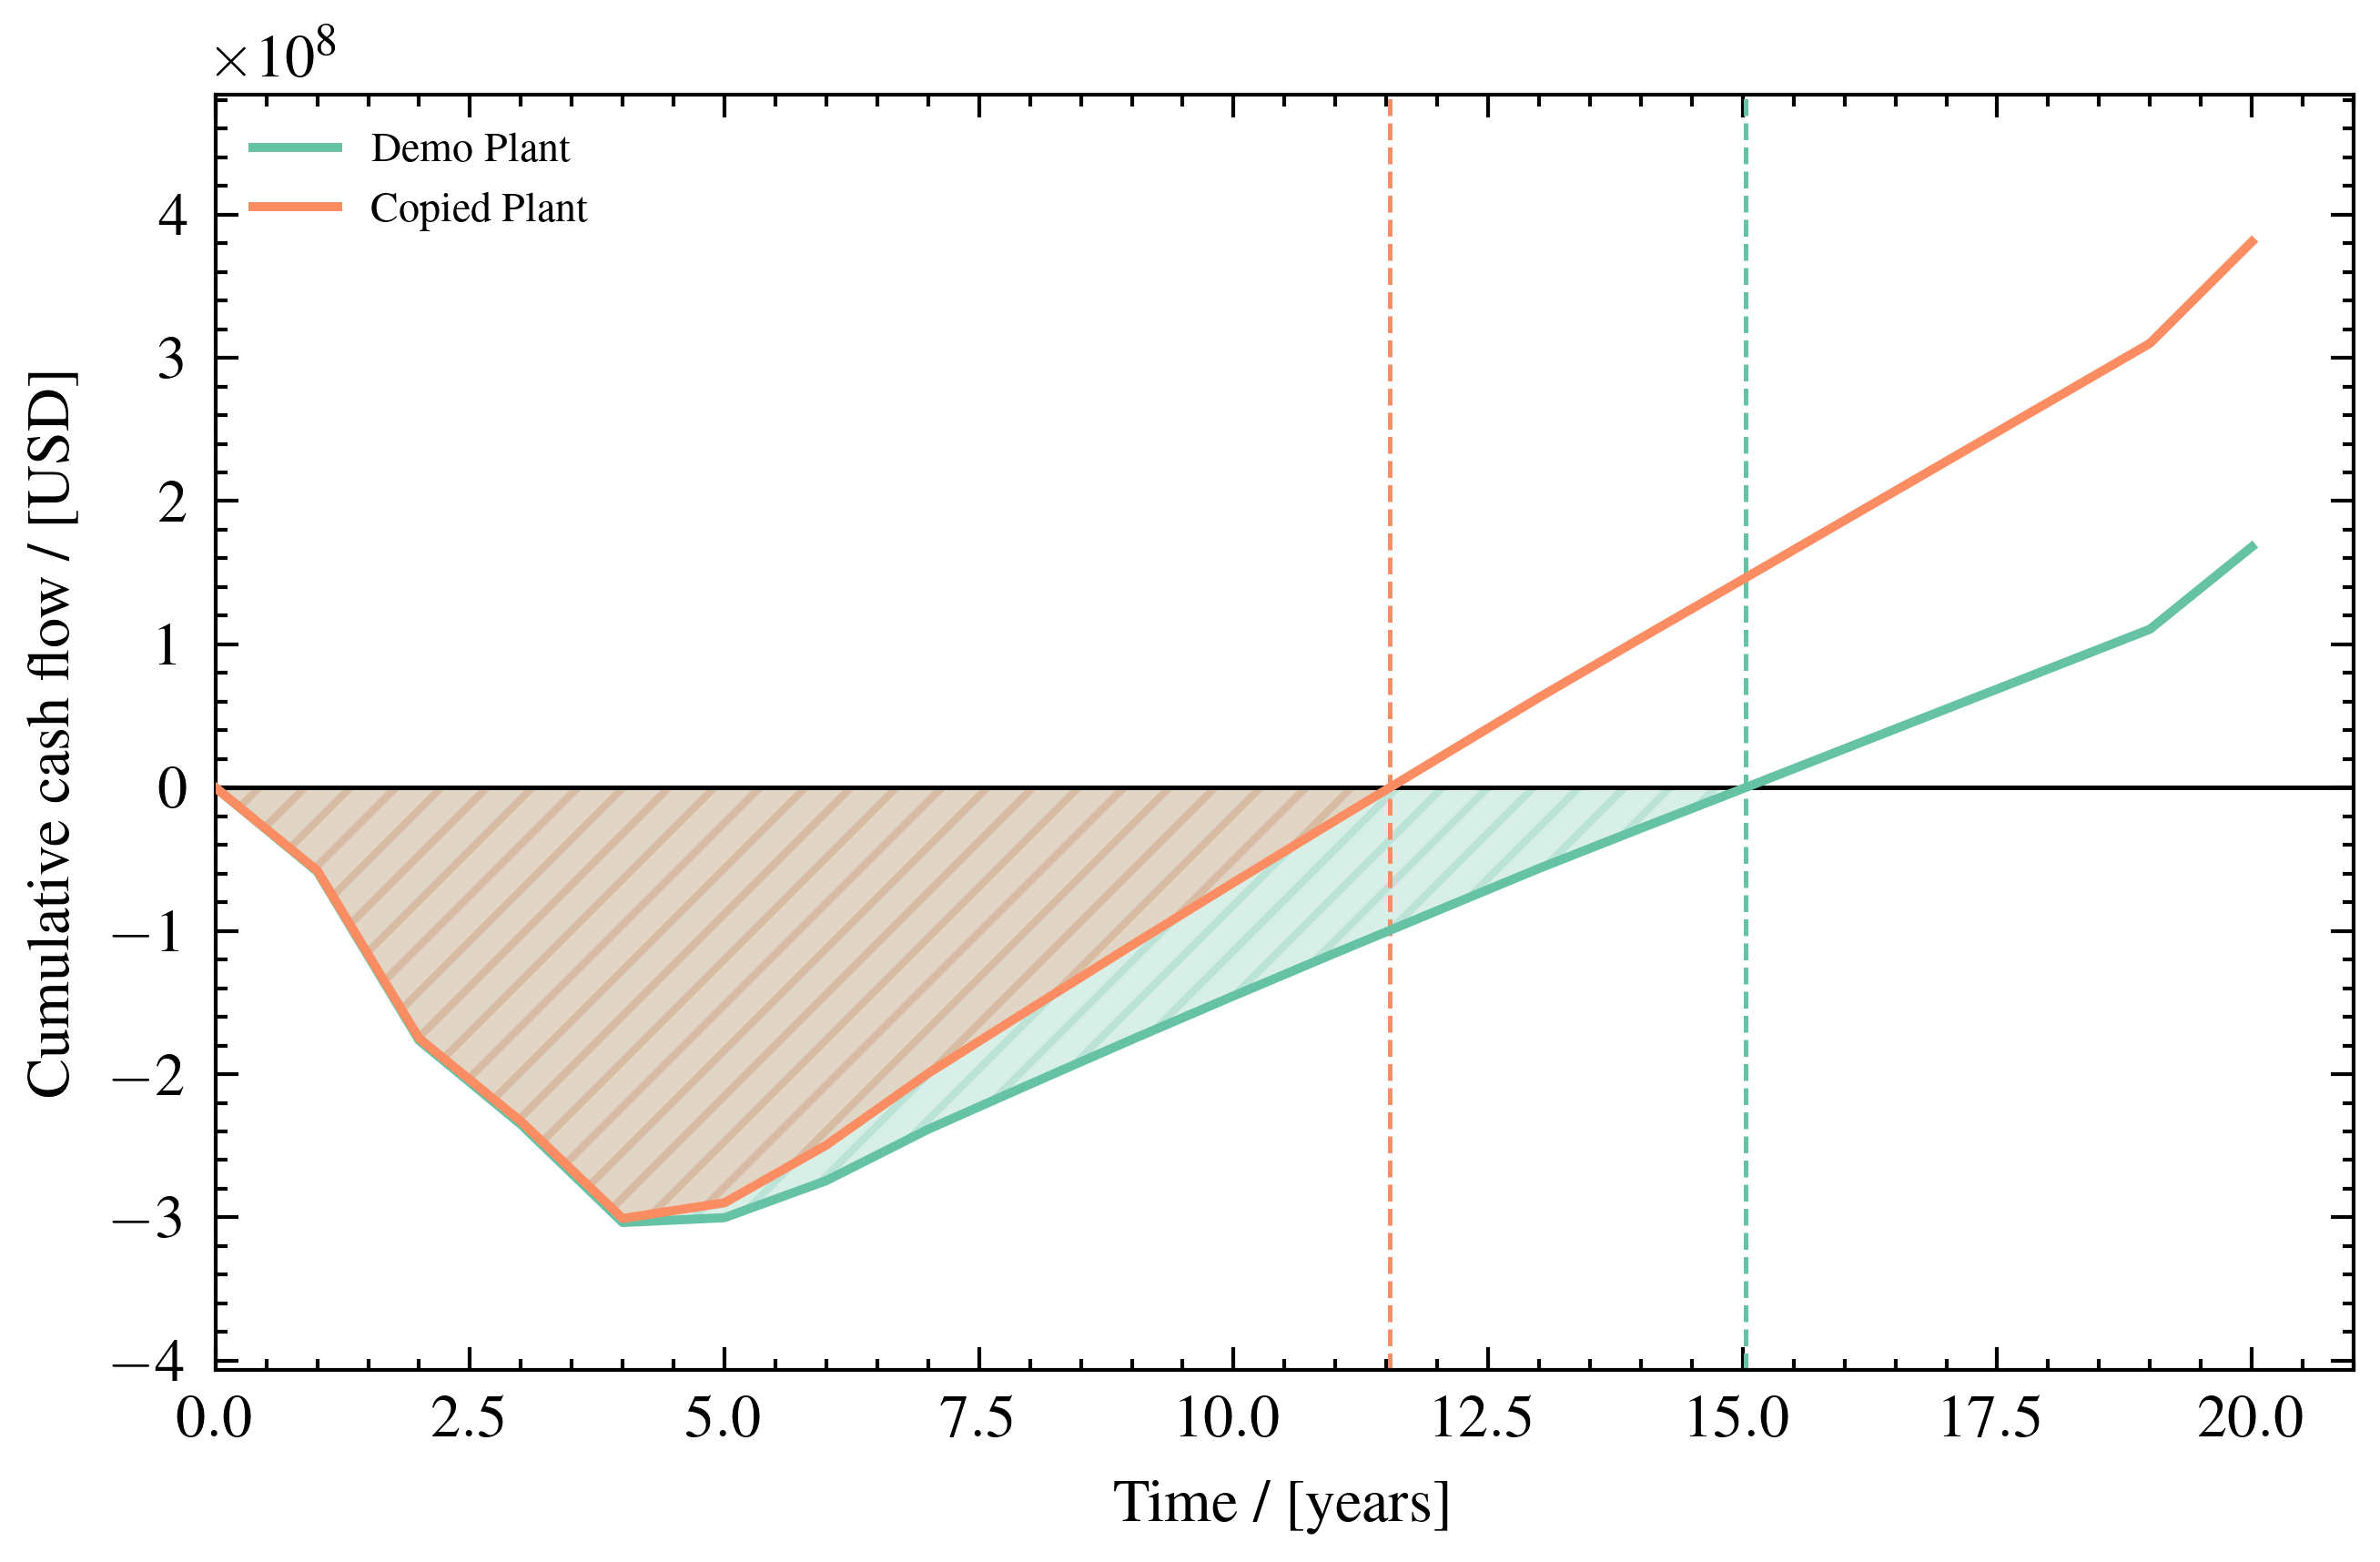

In [13]:
# --- Compare cumulative cash flow across plants ---
cash_flow_multi = cash_flow_data([demo_plant, copy_plant])
fig, ax = plot_cash_flow(cash_flow_multi, figsize=(4.5, 3))

## ⚖️ Sensitivity and Uncertainty Analyses

In TEA, sensitivity analysis helps quantify how uncertainty in key assumptions propagates through the model to affect economic performance.
Parameters such as capital costs, utility prices, operating factors, and financial assumptions rarely remain fixed throughout a project’s life. Understanding which inputs most strongly influence the econmic performance metrics enables better risk management and investment decisions.

This section presents three complementary approaches:

### 📈 One-Way Sensitivity Line Plot

A one-way (deterministic) sensitivity analysis evaluates how a selected output metric responds to changes in a single input parameter, while all other assumptions remain constant.

In this approach, one parameter (for example, fixed capital, interest rate, electricity price, or CO₂ tax) is varied over a defined range. For each value, the plant is re-evaluated and the selected metric is calculated. The results are then plotted, with the input parameter on the x-axis and the metric on the y-axis. Multiple plants or scenarios can be included to enable direct comparison.

This visualization highlights how sensitive the economic performance is to a specific parameter and helps identify key cost drivers or break-even regions.

In **OpenPyTEA**, sensitivity analysis is performed using the function `sensitivity_data()` from the `analysis` module to generate the data, which can then be visualized using `plot_sensitivity()` from the `plotting` module.

If no metric is specified, the levelized cost is used as the default. For example, the sensitivity of the levelized cost to natural gas price can be generated as follows:

In [14]:
lcop_sensitivity = sensitivity_data(plants=demo_plant, parameter="natural_gas", plus_minus_value=0.5)

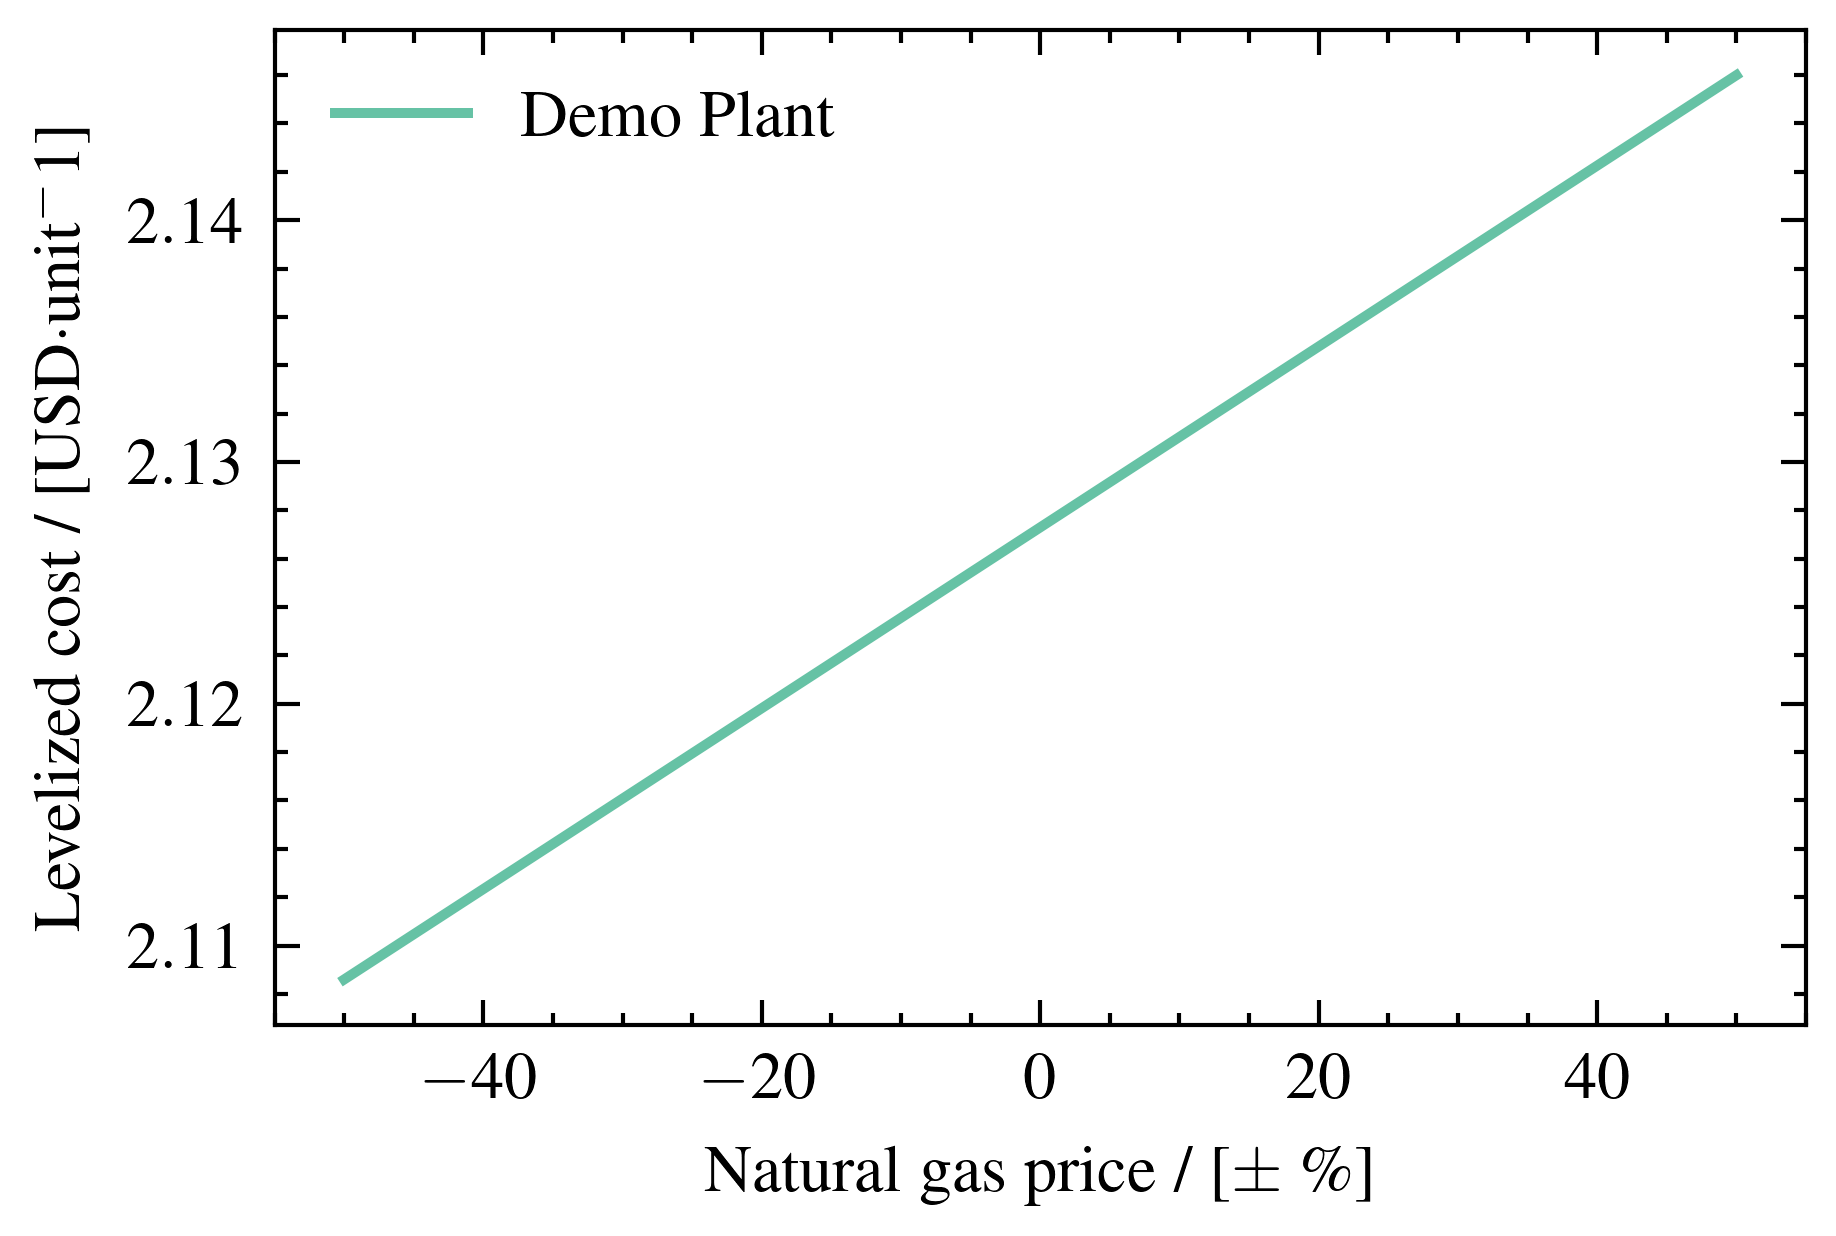

In [15]:
fig, ax = plot_sensitivity(lcop_sensitivity)  # This will create a sensitivity plot showing the impact of a +-50% change in natural gas price on key financial metrics

Besides the `variable_opex_inputs` you can also choose to vary:
- `fixed_capital`
- `fixed_opex`
- `project_lifetime`
- `interest_rate`
- `operator_hourly_rate`
- `plant_utilization`
- `tax_rate`
- `plant_product.price`

and the plant's **process** parameters -- the physical flows rather than their prices:
- `"{item}.consumption"` -- a `variable_opex_inputs` item's consumption rate
- `"{product}.production"` -- a `plant_products` entry's production rate

You can also specify the `metric` you want to evaluate. The selections are `NPV`, `LCOP`, `PBT`, `ROI`, and `IRR`. For example:

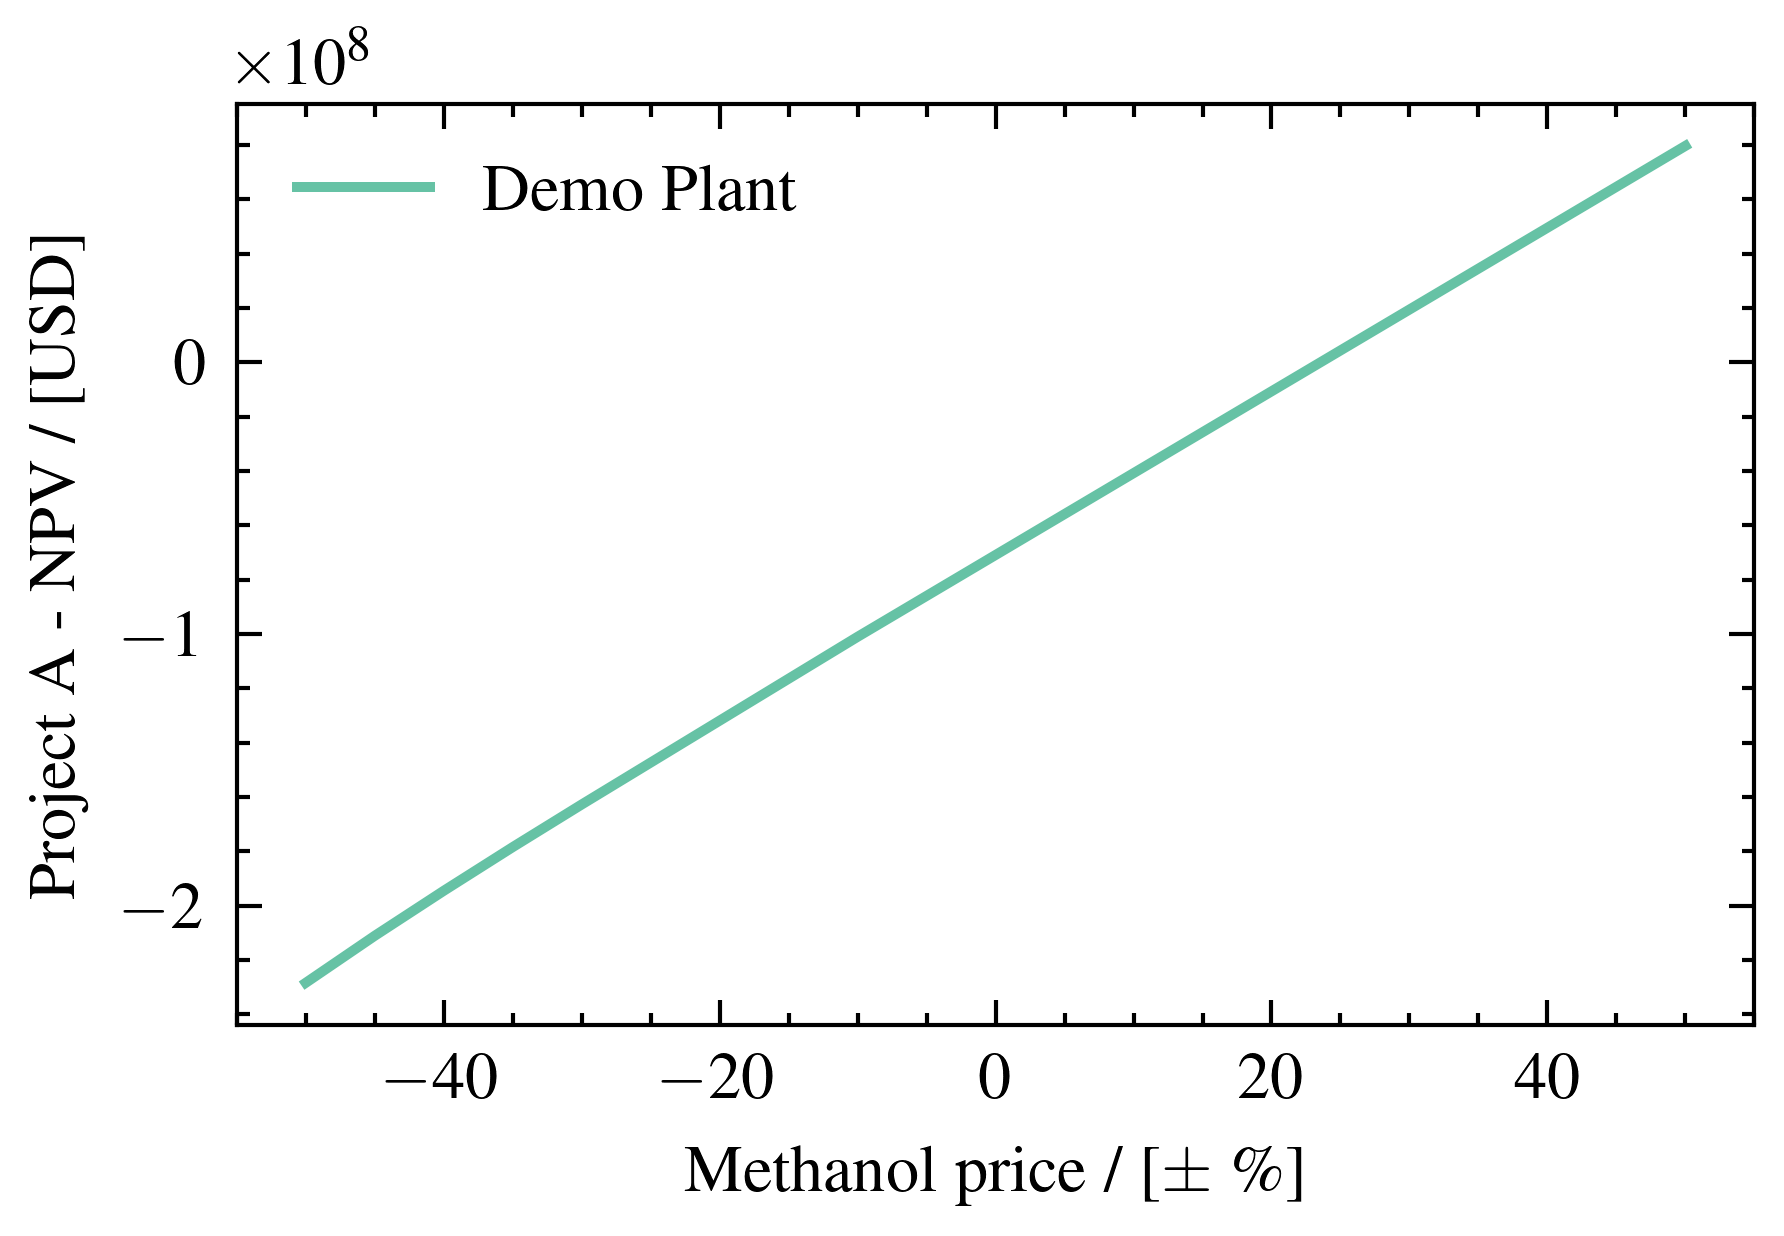

In [16]:
npv_sensitivity = sensitivity_data(plants=demo_plant, parameter="methanol", metric='NPV', plus_minus_value=0.5, label="Project A - NPV / [USD]")  # You can change the plot label like this
fig, ax = plot_sensitivity(npv_sensitivity)

If you have multiple plants, you can compare the sensitivity distribution results in one figure by making the `plants` argument as a list:

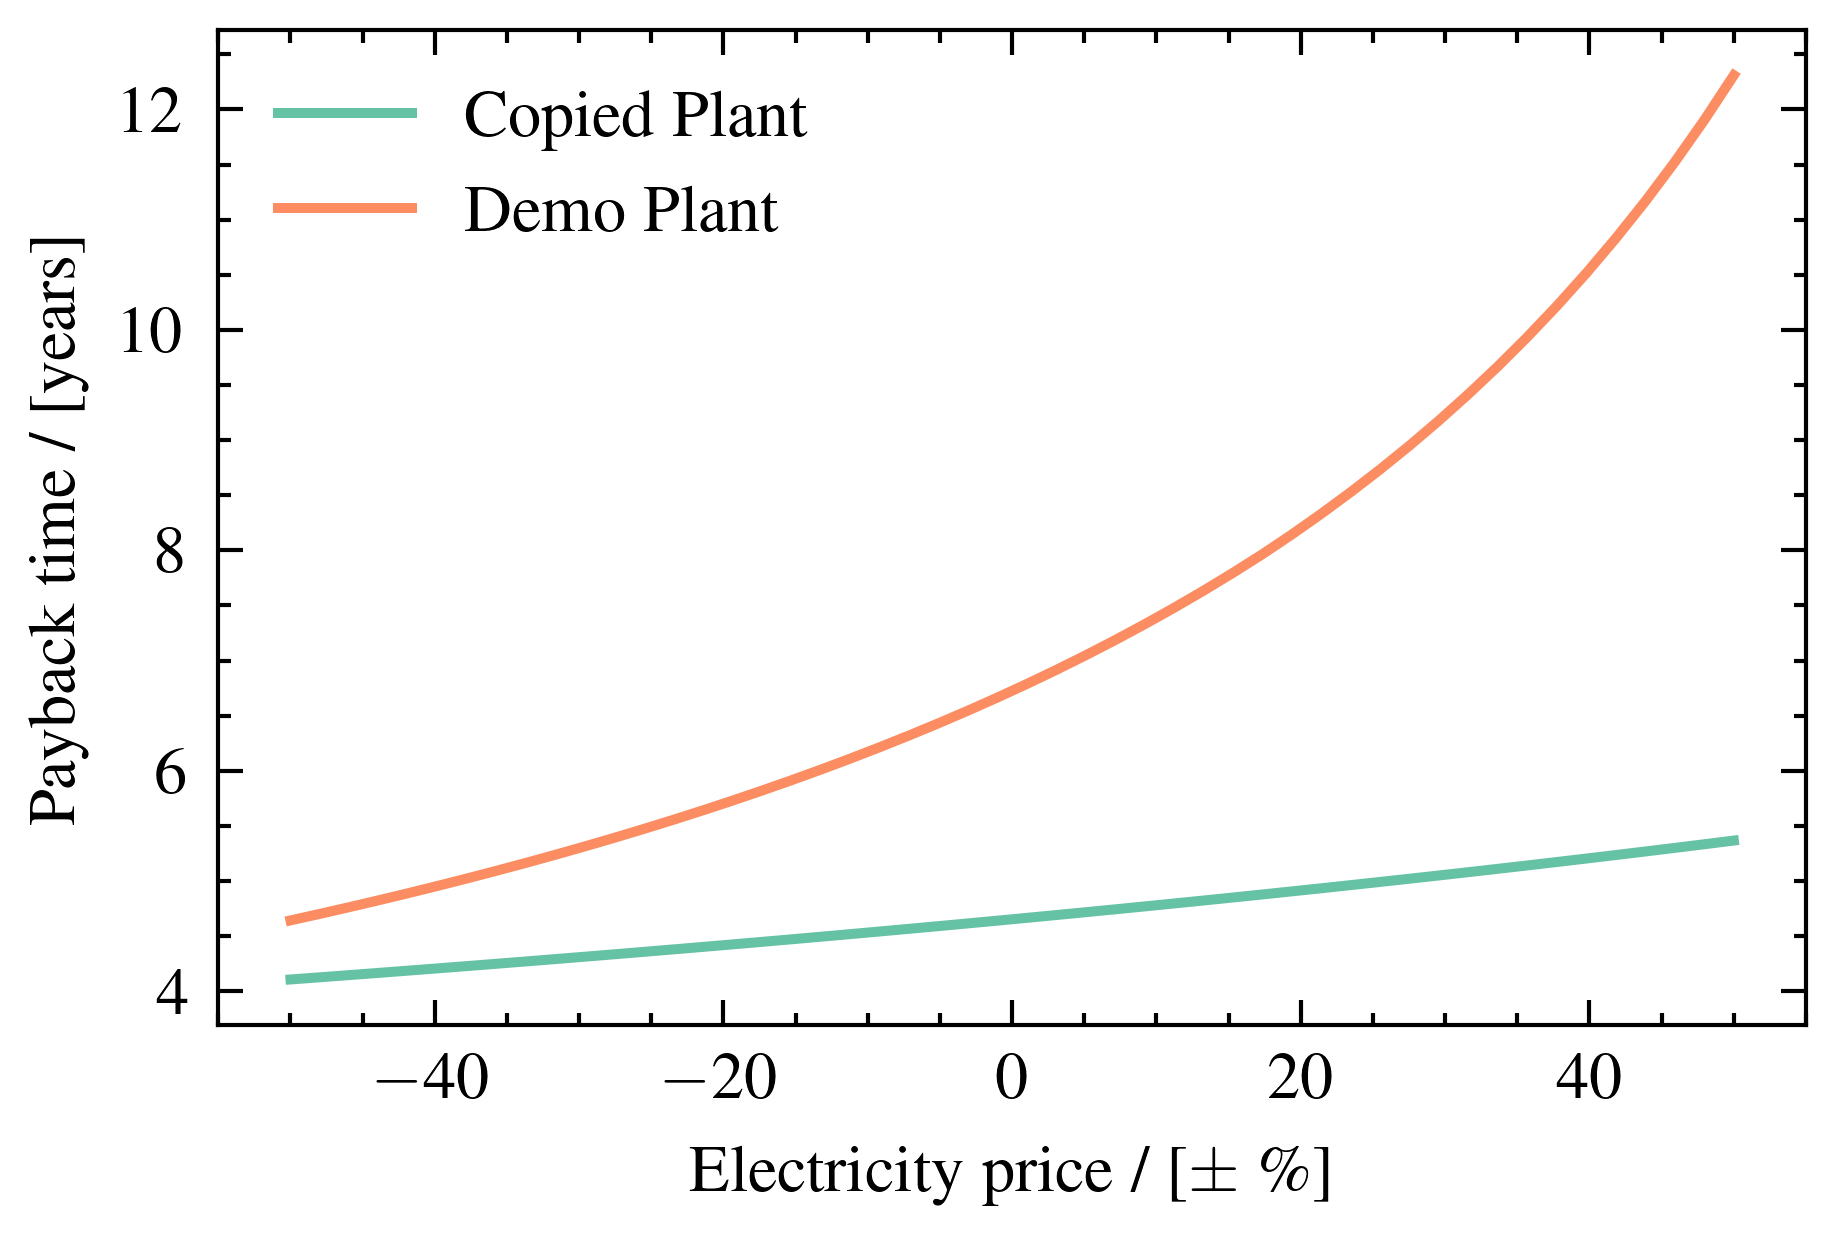

In [17]:
pbt_comparison = sensitivity_data(plants=[copy_plant, demo_plant], 
                                  parameter="electricity", metric='PBT', 
                                  plus_minus_value=0.5, additional_capex=True,
                                  n_points=50)  
fig, ax = plot_sensitivity(pbt_comparison)  # This will create a sensitivity plot showing the impact of a +-25% change in electricity price on PBT for both plants
# We set additional_capex=True to account for additional CAPEX events in the PBT sensitivity

---

**Varying a process parameter**

Everything swept so far has been a *price* or a financial assumption. The physical side of the plant can be swept the same way: name a consumption or production rate instead. Methanol is this plant's main product, so its production rate sits in the denominator of the levelized cost and is worth a look:

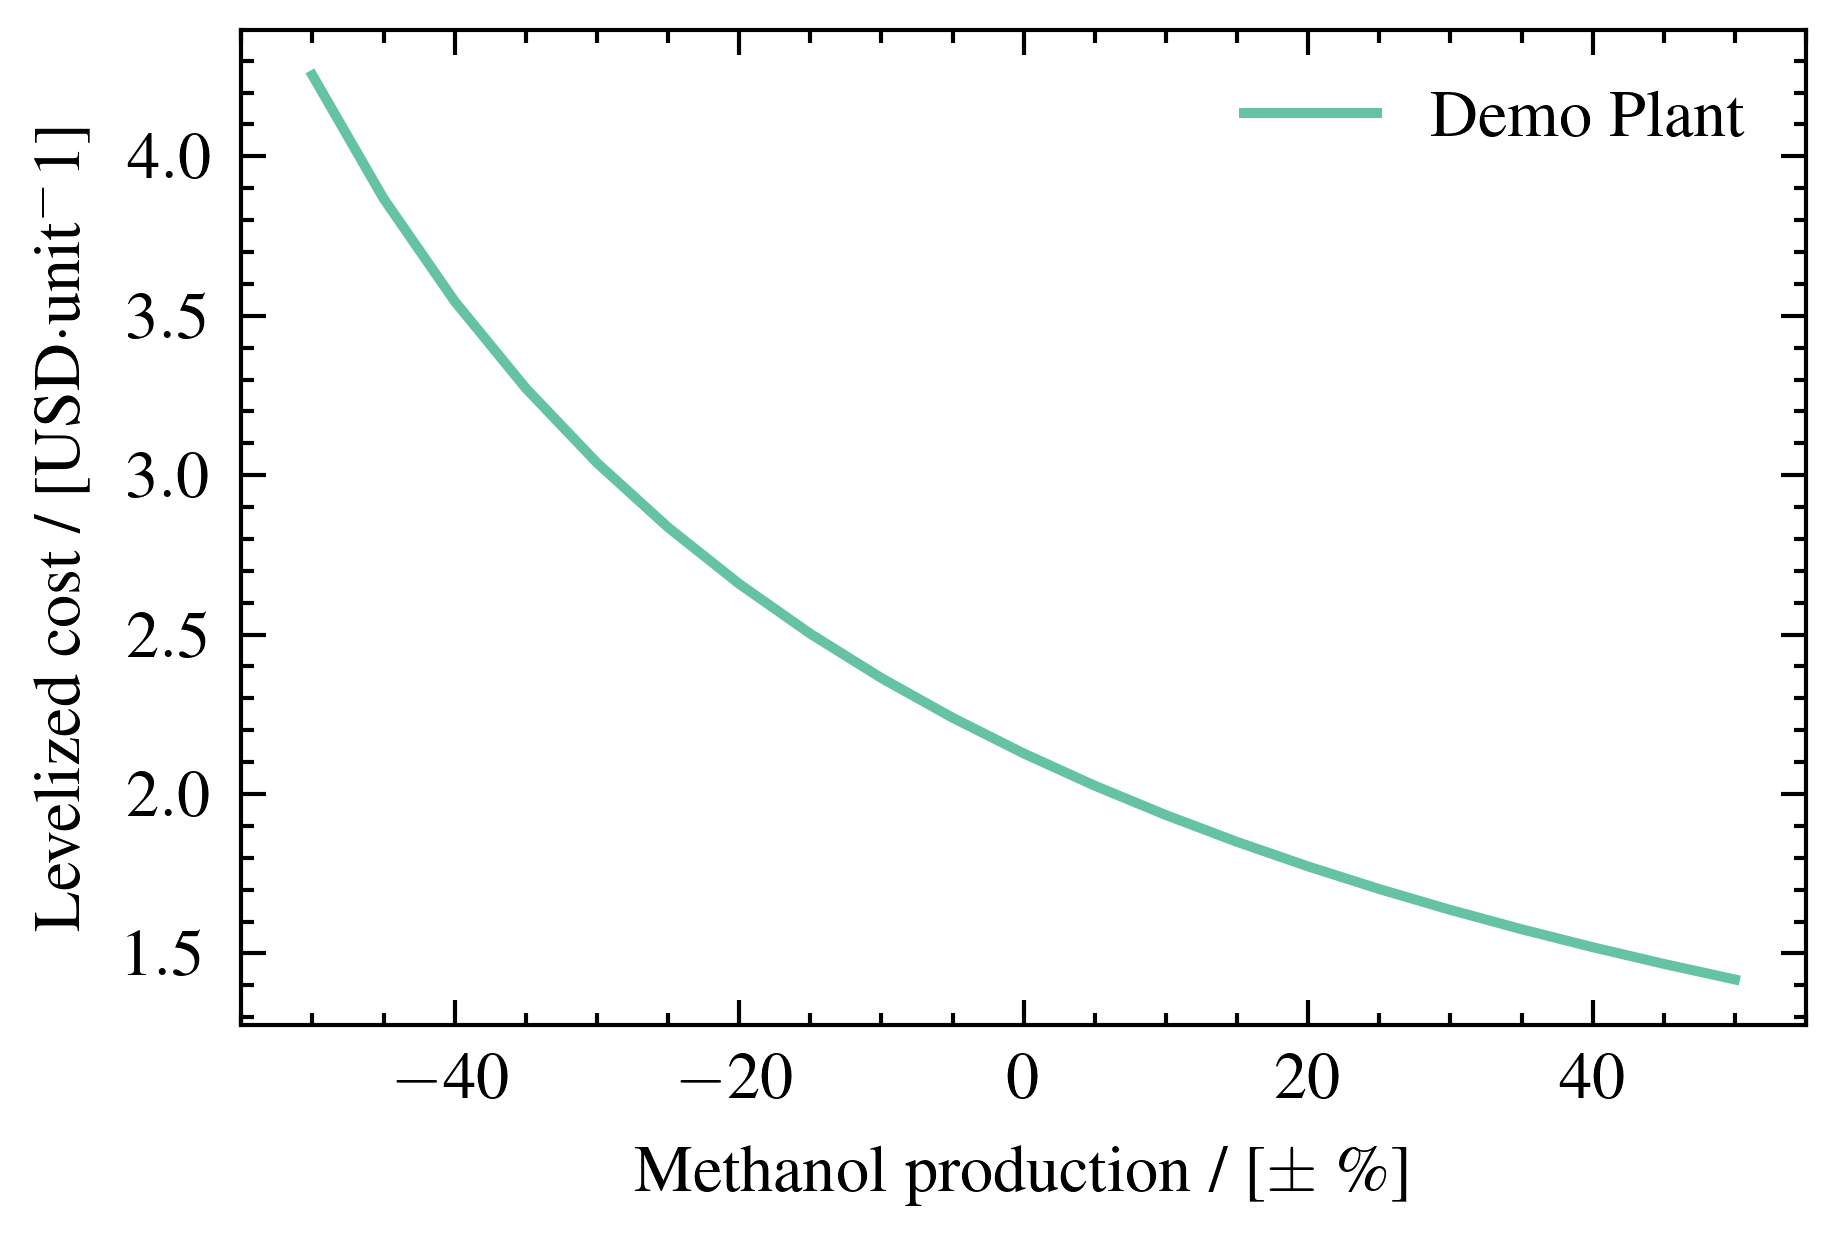

In [18]:
production_sensitivity = sensitivity_data(
    plants=demo_plant,
    parameter="methanol.production",  # Shorthand for "plant_products.methanol.production"
    plus_minus_value=0.5,
)

fig, ax = plot_sensitivity(production_sensitivity)

The curve is steep -- LCOP runs from about 4.25 down to 1.42 USD/unit around a 2.13 baseline -- and it is the familiar shape of fixed costs being spread over more or less output.

> **A caveat worth taking seriously.** A one-way sweep holds *everything else constant*, and for a process parameter that assumption is usually wrong. If this plant really made 50 % less methanol, it would not go on consuming 1,600,000 units/day of cooling water, 400,000 of steam and 100,000 of natural gas, nor would it keep producing 75,000 units/day of hydrogen as a byproduct. Those quantities are tied together by the process itself -- by stoichiometry, by the energy balance, by the equipment actually installed.
>
> So read this curve as *"what if only methanol production moved"*, which is not a state the plant can physically be in. The same caveat applies to the tornado plot below, and more strongly, since it sweeps every process parameter this way.
>
> This is fixable, not just a limitation to be noted. OpenPyTEA lets you declare how these quantities depend on each other, and once you have, **both** `sensitivity_data()` and `tornado_data()` honour those links automatically -- no different call, no extra argument. That machinery is introduced in the Monte Carlo section below, and we return to its effect on these two plots once it is set up.

### 🌀 Tornado Plot (Deterministic Sensitivity)

A one-at-a-time (OAT) sensitivity approach is used to evaluate the impact of individual input parameters on the selected metric. Each parameter is varied by a fixed percentage (for example, ±50%) around its baseline value, while all other parameters remain constant. The resulting change in the metric is calculated for each case.

The results are visualized using a tornado plot, where horizontal bar lengths represent the magnitude of the impact. This allows direct comparison of parameter influence and helps identify the most critical drivers of economic performance. Such insight is useful for prioritizing data refinement and targeting cost-reduction efforts.

You can generate the data for the tornado plot as follows:

In [19]:
tornado_data(plant = demo_plant, plus_minus_value=0.5)  # Function is from the analysis module. If metric is not chosen, LCOP is used by default

C:\Users\pbtamarona\OneDrive - Delft University of Technology\Documents\github-pbtamarona\OpenPyTEA\src\openpytea\plant.py:1356: UserWarning: Depreciation life exceeds the usable horizon (project lifetime minus service start year), so part of the depreciable basis is not written off within the project. This is legitimate for a statutory life longer than the project, but shorten the depreciation life or extend the project lifetime if a full write-off is intended.
  build_depreciation_array(


{'factors': ['variable_opex_inputs.cooling_water',
  'variable_opex_inputs.natural_gas',
  'variable_opex_inputs.steam',
  'operator_hourly_rate',
  'fixed_opex',
  'interest_rate',
  'variable_opex_inputs.electricity',
  'project_lifetime',
  'fixed_capital'],
 'lows': array([2.12131169, 2.10859647, 2.0845551 , 2.06504735, 1.64916751,
        1.66598161, 1.56632997, 3.46687337, 1.33286107]),
 'highs': array([2.13327895, 2.14599416, 2.17003553, 2.18954328, 2.60542312,
        2.69989337, 2.68826066, 1.88743256, 2.92172957]),
 'base_value': np.float64(2.1272953179663165),
 'labels': ['Cooling water price',
  'Natural gas price',
  'Steam price',
  'Operator hourly rate',
  'Fixed OPEX',
  'Interest rate',
  'Electricity price',
  'Project lifetime',
  'Fixed CAPEX'],
 'plus_minus_value': 0.5,
 'metric': 'LCOP',
 'xlabel': 'Levelized cost / [USD$\\cdot$unit$^-1$]'}

Then you generate the plot using `plot_tornado()` function from the `plotting` module:

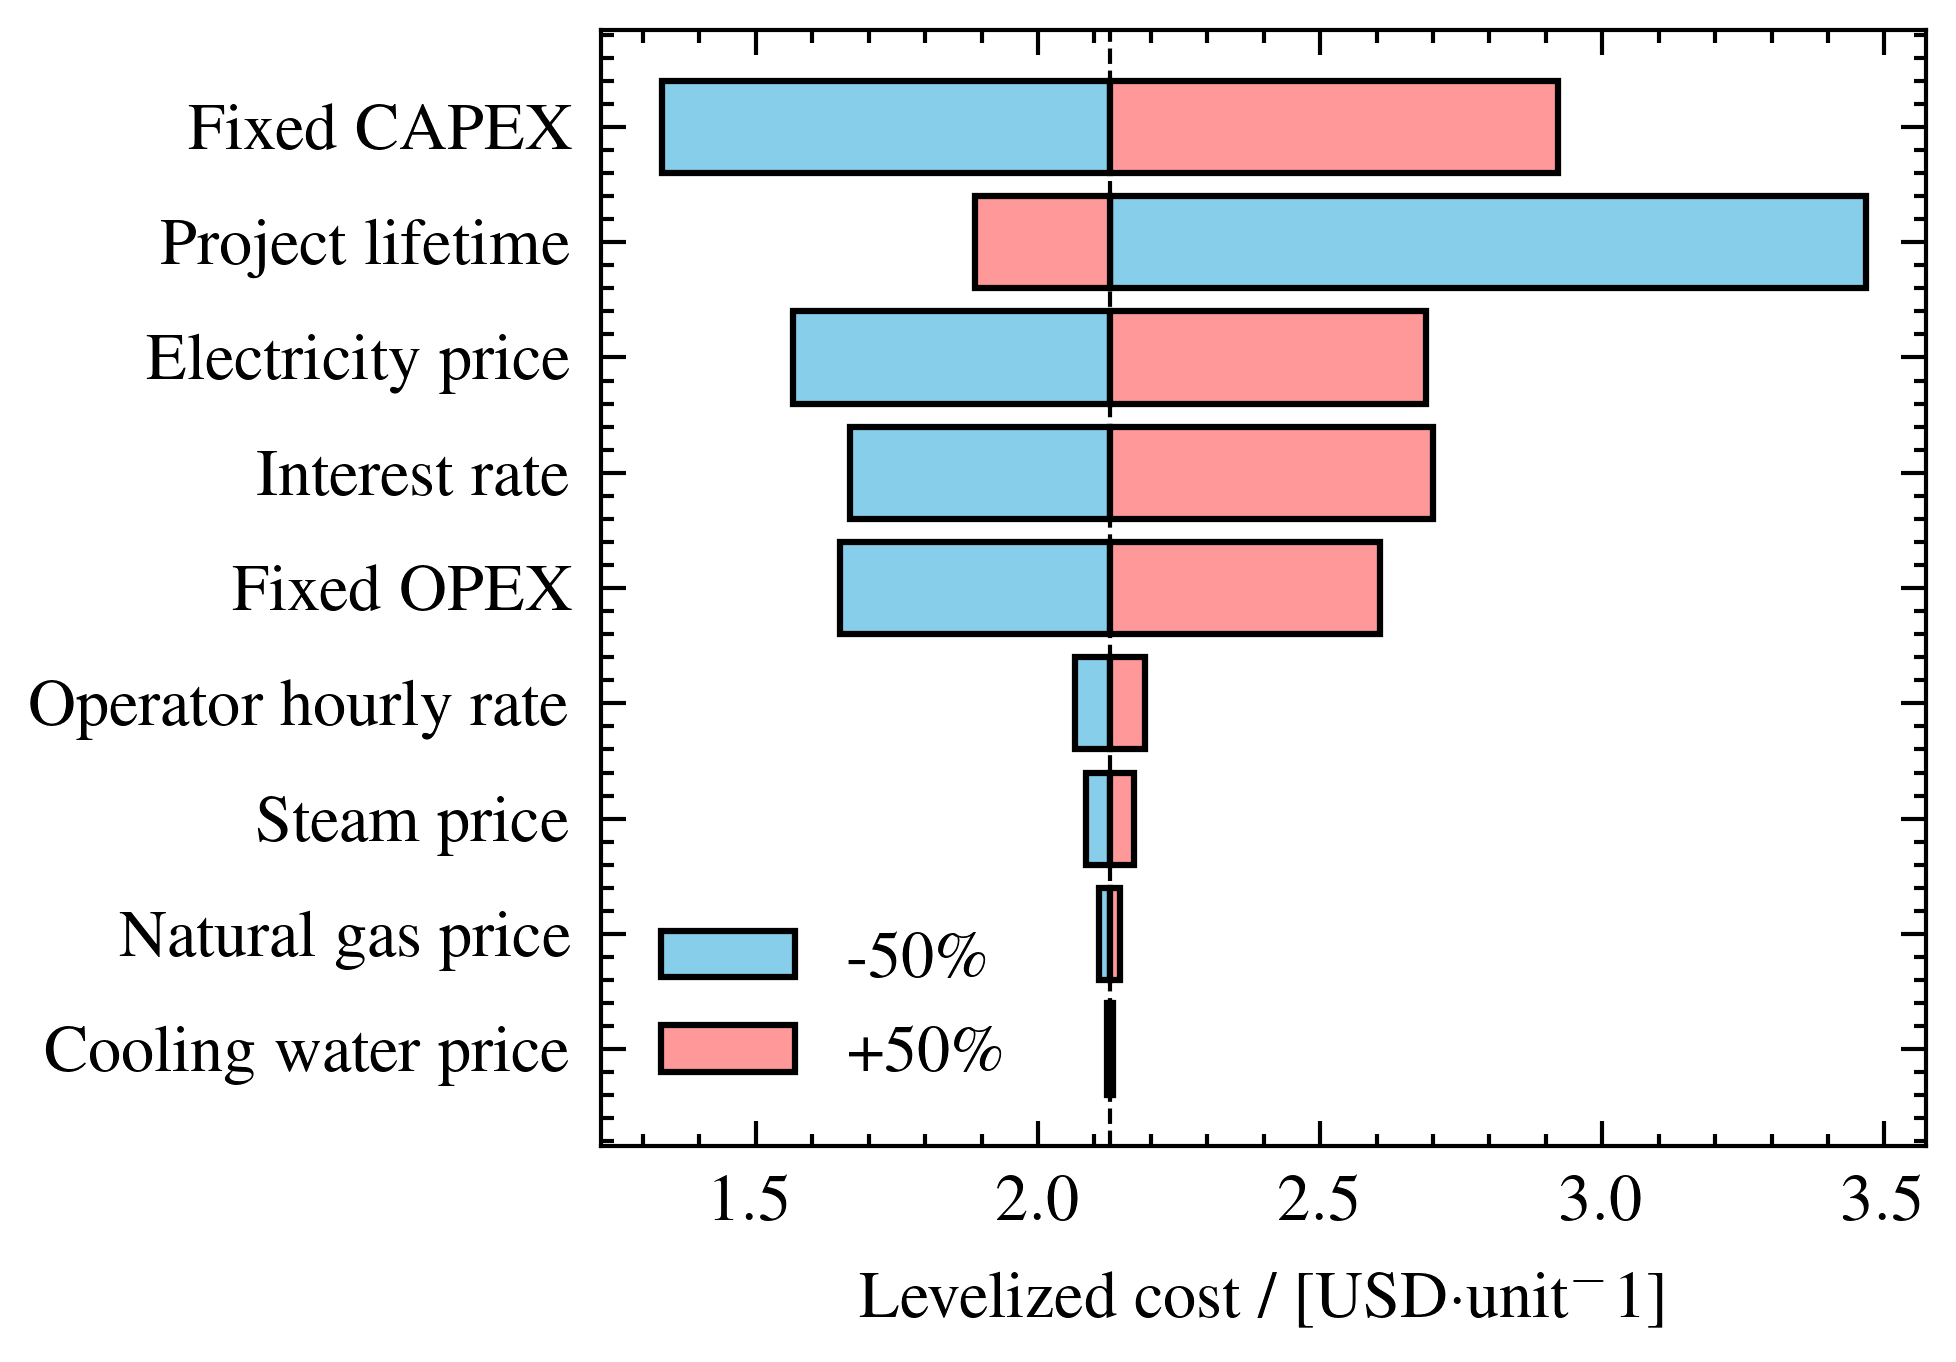

In [20]:
fig, ax = plot_tornado(tornado_data(plant = demo_plant, plus_minus_value=0.5))  # If metric is not chosen, LCOP is used by default

For profit-oriented metrics, the product price(s) are included in the sensitivity evaluation. For example, when evaluating ROI:

C:\Users\pbtamarona\OneDrive - Delft University of Technology\Documents\github-pbtamarona\OpenPyTEA\src\openpytea\plant.py:1356: UserWarning: Depreciation life exceeds the usable horizon (project lifetime minus service start year), so part of the depreciable basis is not written off within the project. This is legitimate for a statutory life longer than the project, but shorten the depreciation life or extend the project lifetime if a full write-off is intended.
  build_depreciation_array(


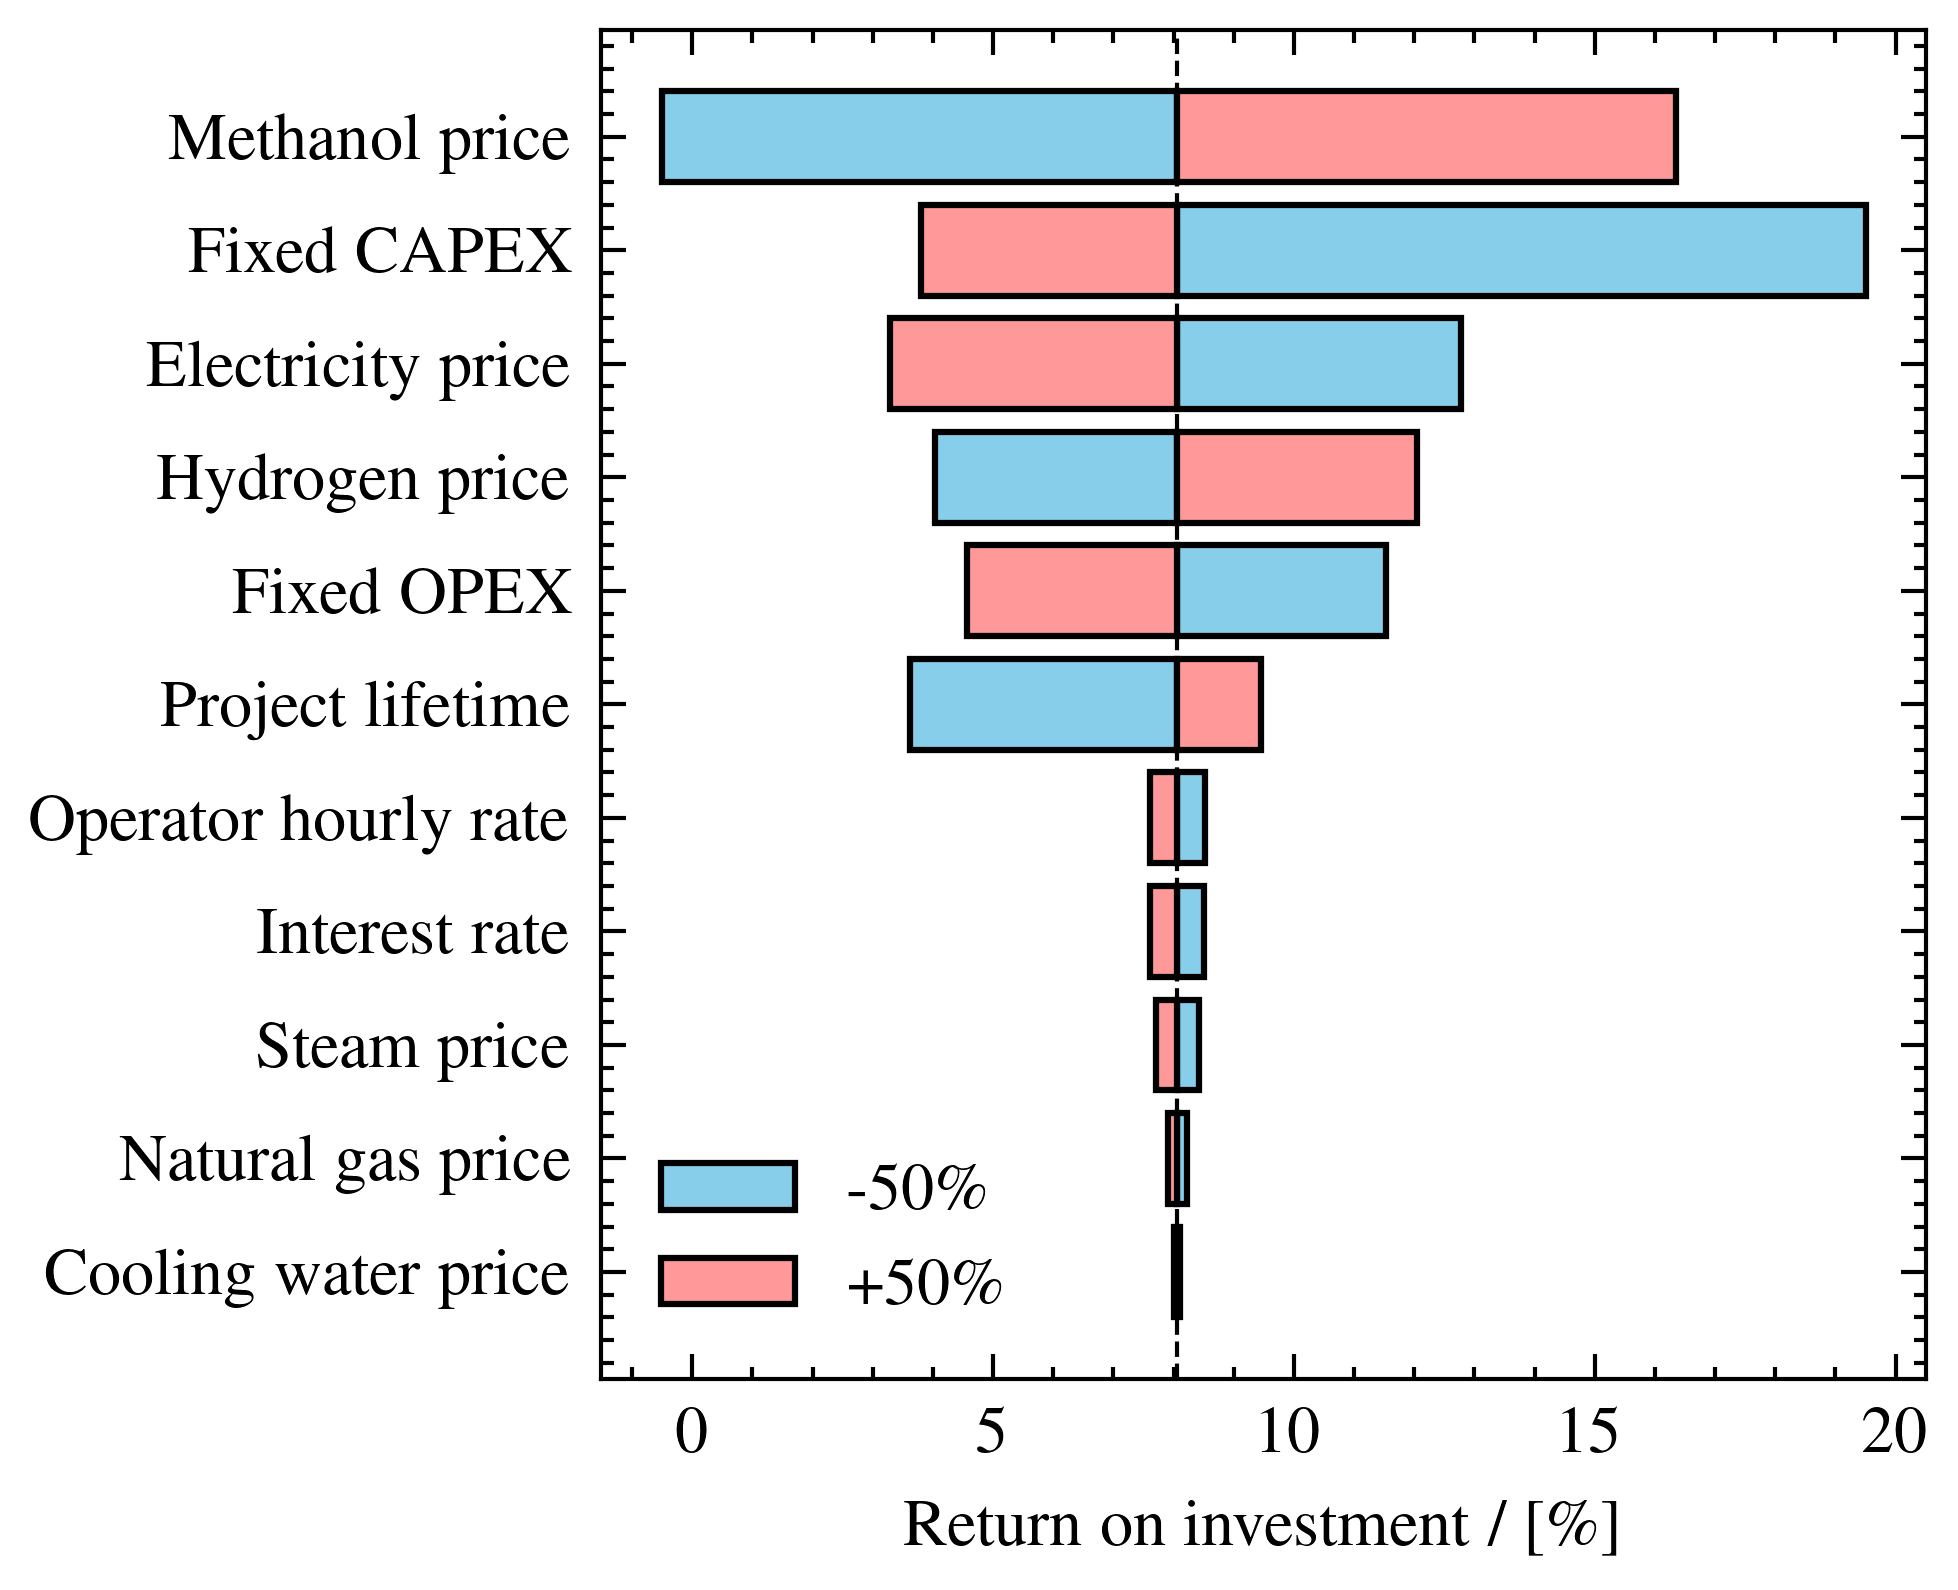

In [21]:
fig, ax = plot_tornado(tornado_data(plant = demo_plant, plus_minus_value=0.5, metric='ROI'))  # If metric is not chosen, LCOP is used by default

---

**Including process parameters**

By default the tornado ranks prices and financial assumptions. Pass `include_process_params=True` to rank the plant's process parameters alongside them -- every item's consumption and every product's production:

C:\Users\pbtamarona\OneDrive - Delft University of Technology\Documents\github-pbtamarona\OpenPyTEA\src\openpytea\plant.py:1356: UserWarning: Depreciation life exceeds the usable horizon (project lifetime minus service start year), so part of the depreciable basis is not written off within the project. This is legitimate for a statutory life longer than the project, but shorten the depreciation life or extend the project lifetime if a full write-off is intended.
  build_depreciation_array(


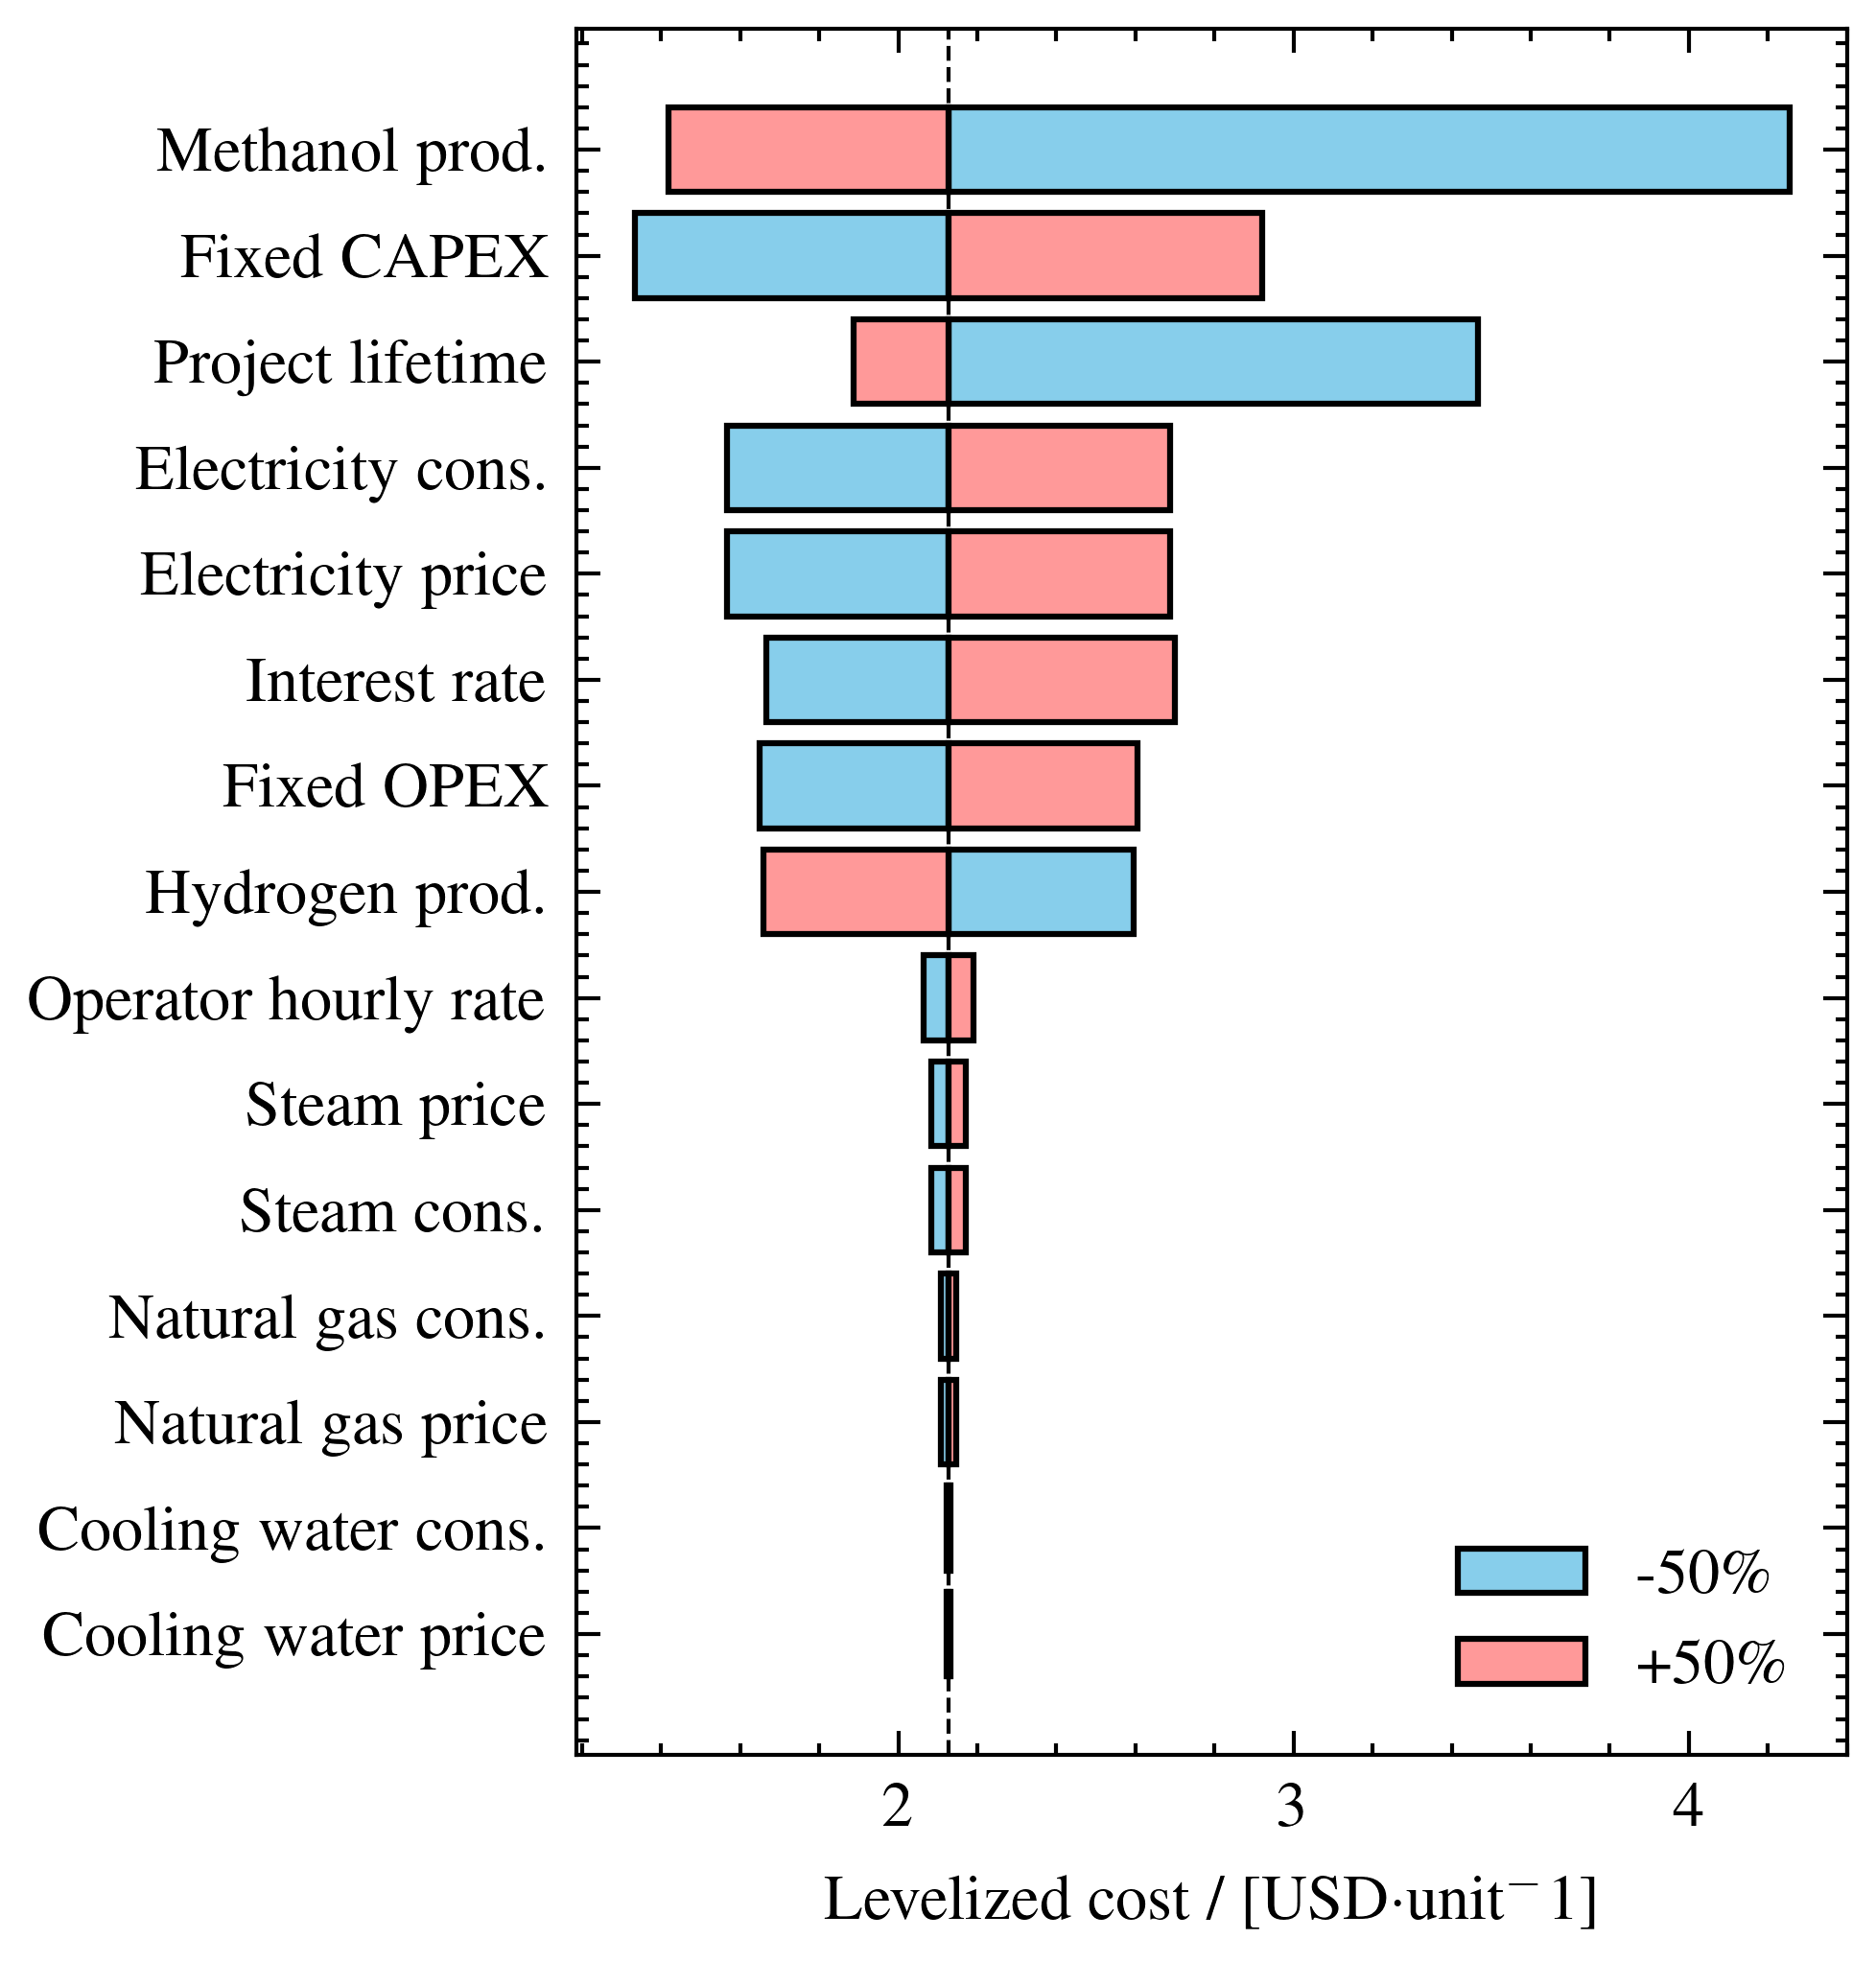

In [22]:
td_process = tornado_data(plant=demo_plant, plus_minus_value=0.5, include_process_params=True)
fig, ax = plot_tornado(td_process)

Two things stand out.

**Each consumption bar exactly matches its own price bar.** Cooling water consumption and cooling water price span the same 0.012 USD/unit; the same holds for steam, natural gas and electricity. That is the arithmetic working as it should -- an item's contribution to variable OPEX is consumption x price, so a +-50 % move in either factor does precisely the same thing to the economics. It is a useful check, and it also means these pairs carry no independent information.

**`Methanol prod.` dominates everything**, spanning 4.25 to 1.42 against a 2.13 baseline -- nearly twice the next largest factor. Output volume, not any single price, is what this plant's levelized cost hinges on.

> **The same caveat as above, and it bites harder here.** A tornado varies each factor *one at a time*, holding all others at their baseline. For prices that is a fair question to ask -- the electricity price really can move while the steam price does not. For process parameters it usually is not: halving methanol production while cooling water, steam, natural gas and hydrogen all stay pinned at their baselines is not a physically reachable scenario, so that bar is not measuring a real alternative.
>
> Treat these bars as an upper bound on each parameter's *isolated* leverage, and see the Monte Carlo section below for how to declare the links between them. Once declared, this very same call picks them up automatically.

---

◀ **Previous:** [Part 2: Creating the Plant](part_2_plant.ipynb) &nbsp;|&nbsp; **Next:** [Part 4: Monte Carlo Uncertainty Analysis](part_4_monte_carlo.ipynb) ▶